# Preamble

Always run this section at least once before doing anything in the notebook. Contains includes and configurations.

## Imports

In [ ]:
import math
from statistics import fmean
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import plot_confusion_matrix
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

# regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# classifier models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
# import m2cgen as m2c
import onnxmltools
# # from onnxconverter_common.data_types import FloatTensorType
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

SEED_VALUE = 42 # Fix seed to make training deterministic.
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# suppress some print msgs from tf. daming sinasabi
tf.get_logger().setLevel('WARNING')

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Utility Functions

In [ ]:
def loadFile(fn, skip_rows=None):
  workingDir = "/content/drive/MyDrive/CoE 199 (2s2425)/Algal Samples/"
  csvPath = workingDir + fn
  return pd.read_csv(csvPath, skiprows=skip_rows)

def createData(df_raw):
    x, y = df_raw['AS7343'].to_numpy().reshape(-1, 1), np.array([df_raw['MSI_ref']]).reshape(-1,1)

    # 80:20 train-test split, randomized
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True, random_state=15)

    # store data on dict for easier access
    data = {
        'X_all':    x,
        'y_all':    y,
        'X_train':  X_train,
        'y_train':  y_train,
        'X_test':   X_test,
        'y_test':   y_test,
    }

    return data

def calcBaseline(df, plotResults=True):
    x_raw = np.array(df['AS7343']).reshape((-1, 1))
    y_raw = np.array(df['MSI_ref']).reshape((-1, 1))

    sr2 = round(r2_score(x_raw, y_raw), 5)
    smse = round(np.sqrt(mse(x_raw, y_raw)), 5)
    slope, intercept, r, p, sterr = stats.linregress(x=x_raw.ravel(), y=y_raw.ravel())
    if (plotResults):
        plotScatter('Baseline', sr2,  smse, x_raw, y_raw)
    else:
        print('stats r2:', round(r**2, 5), ', intercept:', intercept, ', r:', r,  ', p:', p, ', stderr:', sterr)
        print('  metrics r2:', sr2)
        print('  rmse:', smse)
        print('')

    return sr2, smse

def trainModel(model, data, channel, plotResults=True):
    model.fit(data['X_train'], data['y_train'])
    y_pred = model.predict(data['X_test'])

    y_test = data['y_test']
    cn = model.__class__.__name__
    cn += f" {channel}"
    print('Performance Metrics:', cn)
    sr2 = round(r2_score(y_test, y_pred), 5)
    smse = round(np.sqrt(mse(y_test, y_pred)), 5)

    if (plotResults):
        plotScatter(cn, sr2, smse, data['X_test'], y_test, y_pred)
    else:
        print('  metrics r2:', sr2)
        print('  rmse:', smse)
        print('')

    # return calibrated values for every sensor reading
    return data['X_test'], y_pred, sr2, smse, model

def calibrateSpectrum(spectrum, models, form='ndarray', column=''):
  """Takes spectrum and calibrates each reading.\n

  Parameters:
  spectrum: arrayLike - array of readings
  models: arrayLike - array containing models for each channel. must be the same length as spectrum
  form: str = {'ndarray', 'list', 'df'} format of output
  column: str = '' optional; column name to be used for dataframe
  """

  assert len(list(spectrum)) == len(models) # raise error if unequal

  calibratedSpectrum = np.array([]).reshape(-1,1)

  for i in range(len(models)):
    calibratedReading = models[i].predict(np.array(spectrum[i].reshape(-1,1)))
    calibratedSpectrum = np.concat((calibratedSpectrum, calibratedReading))

  match (form):
    case 'df':
      return pd.DataFrame(calibratedSpectrum.reshape(-1,1), columns=[column])
    case 'list':
      return list(calibratedSpectrum)
    case _: # for case ndarray and other arguments
      return calibratedSpectrum.reshape(-1,1)


def raw_to_abs(raw_fn):
  """Take a csv file of raw outputs and output a corresponding csv file
  of absorbances. This does the entire thing from file loading, absorbance
  computation, and finally writing the .csv of absorbances.

  Will automatically pull the raw file from the 'Raw/' subfolder, and save
  absorbances as csv with the same filename (no subfolder). So just input the filename."""

  raw_df = loadFile('Raw/' + raw_fn)

  abs_df = raw_df['wavelength'].copy()

  densities = raw_df.columns[1:]
  blank = np.array(raw_df.iloc[:,1])
  print(blank)
  # blank = np.array([fmean(raw_df.iloc[i,1:11]) for i in range(8)])

  for i in range(1, len(densities)): # exclude blank (0th column)
    density = densities[i]
    spectrum = raw_df.iloc[:,i+1].to_numpy()
    print(spectrum)
    abs_per_dens = np.array([])

    for i in range(len(spectrum)):
      abs = np.array([math.log(blank[i].item()/spectrum[i].item(), 10)])
      abs_per_dens = np.concat((abs_per_dens, abs), axis=0)

    abs_per_dens_df = pd.DataFrame(abs_per_dens.reshape(-1,1), columns=[density])
    abs_df = pd.concat([abs_df, abs_per_dens_df], axis=1)

  abs_df.to_csv(global_fp + 'Abs/' + raw_fn, index=False)

  return abs_df

def fetch_filelist():
  chlo1_fn_list = sorted(os.listdir(global_fp + "MSI Reference/chlo1/"))
  diat1_fn_list = sorted(os.listdir(global_fp + "MSI Reference/diat1/"))
  dino1_fn_list = sorted(os.listdir(global_fp + "MSI Reference/dino1/"))
  dino2_fn_list = sorted(os.listdir(global_fp + "MSI Reference/dino2/"))
  dino3_fn_list = sorted(os.listdir(global_fp + "MSI Reference/dino3/"))

  # compile into a list of lists in case we ever want to iterate over all 5 species
  refs_fn_list = [
    ["MSI Reference/chlo1/" + fn for fn in chlo1_fn_list],
    ["MSI Reference/diat1/" + fn for fn in diat1_fn_list],
    ["MSI Reference/dino1/" + fn for fn in dino1_fn_list],
    ["MSI Reference/dino2/" + fn for fn in dino2_fn_list],
    ["MSI Reference/dino3/" + fn for fn in dino3_fn_list],]

  return refs_fn_list

## Plot functions

In [ ]:
def plotSpectrum(X_dict, title):
    for name, spectrum in X_dict.items():
        plotSpectrumSingle(spectrum, name)
    # plt.legend()
    plt.tick_params(axis='x', labelsize=tick_label_size)
    plt.tick_params(axis='y', labelsize=tick_label_size)
    plt.xlabel("Channel wavelength (in nm)", fontsize=axis_label_size)
    plt.ylabel("Absorbance", fontsize=axis_label_size)
    plt.title(title)
    plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
                      ncols=2, mode="expand", borderaxespad=0., fontsize=lgnd_label_size)
    plt.show()

def plotSpectrumMSI(abs_dict, wavelengths, title):
    for name, spectrum in abs_dict.items():
        plt.plot(wavelengths, spectrum, label=name)
    plt.xlabel("Channel wavelength (in nm)")
    plt.ylabel("Absorbance")
    plt.title(title)
    # plt.legend()
    plt.show()

def plotSpectrumSingle(y, plt_label):
    """Helper function; plots a single spectrum onto an existing figure."""

    assert len(y) == 8
    ch = [450, 475, 515, 550, 555, 600, 640, 690]
    plt.plot(ch, y, label=plt_label)

def plotScatter(title, sr2, smse, x, y_raw, y_calibrated=None):
    # Format the metrics as text
    tlbl = "Metrics"
    tr2 = f"$R^2$: {sr2}"
    trmse = f"RMSE: {smse}"
    # Add the text to the plot
    plt.text(0.05, 0.95, tlbl, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
    plt.text(0.05, 0.88, tr2, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.82, trmse, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')
    plt.text(0.05, 0.76, tmae, transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')

    plt.scatter(x, y_raw, label="Raw Data")
    if (y_calibrated is not None):
        plt.scatter(x, y_calibrated, label="Calibrated Data")

    plt.legend()
    plt.xlabel("AS7343 readings")
    plt.ylabel("Target Value")
    plt.title(f"{title} Scatter Plot")
    plt.show()

def plotRegression(ch, model, x, y_target):
    step_size = 0.001
    x_input = np.arange(0,x.max()+step_size, step_size)

    # , edgecolor='Red', facecolor='none'
    plt.scatter(x, y_target, label="Actual Data", s=20.0)

    for mdl in model:
      y_pred = mdl.predict(x_input.reshape(-1, 1))
      plt.plot(x_input, y_pred, label=f'{mdl.__class__.__name__}')
    plt.ylabel("Expected Readings")
    plt.xlabel("Obtained Readings")
    plt.title(f"{ch} nm Channel Regression Model/s")
    plt.legend()
    plt.show()


def plotMetric(metric_dict, metric, exclude_baseline=False):
    """Plots RMSE scores of each model across all channels."""
    ch = [450, 475, 515, 550, 555, 600, 640, 690]

    mdl_idx=0
    if (exclude_baseline):
      start = 1
    else:
      start = 0

    # x_base = list(range(len(metric_dict[list(metric_dict.keys())[0]])))
    x_base = range(len(ch))
    barWidth = 1/(5+1-1)
    # barWidth = 1/(len(metric_dict)+1-start) # 5 = num of models + 1

    for model in list(metric_dict.keys())[start:5]:
      if len(metric_dict[model]) <= 0:
        continue
      x_input = [x+(barWidth*mdl_idx) for x in x_base]
      plt.bar(x_input, metric_dict[model][:8], label=str(model), width=barWidth)
      mdl_idx+=1

    plt.xticks([x+(barWidth*0.5) for x in x_base], labels=ch)

    Y_MAX = max([max(model_metrics) for model_metrics in list(metric_dict.values())[start:5]])
    plt.ylim(top=1.1*Y_MAX)

    plt.legend(bbox_to_anchor=(1, 1),
               loc='upper left',
              #  ncols=2,
              #  mode="expand",
              #  borderaxespad=0.,
               fontsize=lgnd_label_size)
    plt.xlabel("Channel (in nm)", fontsize=axis_label_size)
    plt.ylabel(f"{metric}", fontsize=axis_label_size)
    plt.tick_params(axis='x', labelsize=tick_label_size)
    plt.tick_params(axis='y', labelsize=tick_label_size)
    # plt.title(f"{metric} of different ML models")
    plt.grid(True, axis='y',which='major')
    plt.show()

## Constants

In [ ]:
chlo1_fn = "chloro1_SP012-ORA2.csv"
diat1_fn = "diat1_p.nitzchia.csv"
dino1_fn = "dino1_t.tetrahele.csv"
dino2_fn = "dino2_pavlova.csv"
dino3_fn = "dino3_s.zamba.csv"

species_list = ["chlo1", "diat1", "dino1", "dino2", "dino3"]
sensor_fn_list = [chlo1_fn, diat1_fn, dino1_fn, dino2_fn, dino3_fn]

species_names = {"chlo1": "SP012-ORA2", "diat1": "p. nitzchia", "dino1": "t. tetrahele", "dino2": "pavlova", "dino3": "s. zambalensis"}
species_groups = {"chlo1": "chlorophyte", "diat1": "diatom", "dino1": "dinoflagellate", "dino2": "dinoflagellate", "dino3": "dinoflagellate"}

percents = loadFile('Raw/'+sensor_fn_list[0]).columns[1:].astype('int64')
print(percents)

ch_str = ["450", "475", "515", "550", "555", "600", "640", "690"]
ch_int = [int(ch) for ch in ch_str]

global_fp = "/content/drive/MyDrive/CoE 199 (2s2425)/Algal Samples/"


reps = 10
n_conc = 22
n_species = 5

# for plotting
axis_label_size = 26
tick_label_size = 20
lgnd_label_size = 20

Index([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  25,  30,  35,
        40,  45,  50,  60,  70,  80,  90, 100],
      dtype='int64')


# Raw to Abs (SKIP)

Convert all the raw readings to absorbances first and save as csv. No need to run multiple times if the files already exist.

In [ ]:
conversion_done = True

if (not conversion_done):
  for file in sensor_fn_list:
    raw_to_abs(f'Reps/{file}')
  print('Saved per species files in Abs folder.')
else:
  print('Conversion already done. Skipping this part...')

Conversion already done. Skipping this part...


For Jehad's sensor readings

In [ ]:
fn = 'jehad.csv'
raw_to_abs(fn)

[51985 41515 41700 12683 62912 49375 30813  1707]
[11375  6275  3194 11369 28444 35346 26358  1351]
[ 8715 10687 39122 11745 60313 48543 29803  1480]
[12151 13519 36592 10902 46380 30431 13369  1486]
[51485 40087 35404  9291 34049 14584  4568  1482]
[26291 16970 10482 10417 25466 20810  9921  1417]


,wavelength,red,ylw,grn,blu,vio
0,450nm,0.659927,0.775611,0.631266,0.004197,0.296071
1,475nm,0.820591,0.589349,0.487260,0.015201,0.388523
2,515nm,1.115801,0.027715,0.056750,0.071084,0.599692
3,550nm,0.047500,0.033369,0.065716,0.135160,0.085479
4,555nm,0.344743,0.018323,0.132403,0.266629,0.392773
5,600nm,0.145167,0.007380,0.210191,0.529630,0.375235
6,640nm,0.067822,0.014474,0.362635,0.829008,0.492179
7,690nm,0.101578,0.061972,0.060215,0.061385,0.080864


# Plot Spectrum (Dyed Water)

In [ ]:
colors = ['red', 'ylw', 'grn', 'blu', 'vio']
color_names = {'red': 'red', 'ylw': 'yellow', 'grn': 'green', 'blu': 'blue', 'vio': 'violet'}
color_shade = {'red': 'red', 'ylw': 'orange', 'grn': 'green', 'blu': 'blue', 'vio': 'purple'}
wavelengths = [450, 475, 515, 550, 555, 600, 640, 690]

  wavelength       red       ylw       grn       blu       vio
0      450nm  0.659927  0.775611  0.631266  0.004197  0.296071
1      475nm  0.820591  0.589349  0.487260  0.015201  0.388523
2      515nm  1.115801  0.027715  0.056750  0.071084  0.599692
3      550nm  0.047500  0.033369  0.065716  0.135160  0.085479
4      555nm  0.344743  0.018323  0.132403  0.266629  0.392773
5      600nm  0.145167  0.007380  0.210191  0.529630  0.375235
6      640nm  0.067822  0.014474  0.362635  0.829008  0.492179
7      690nm  0.101578  0.061972  0.060215  0.061385  0.080864


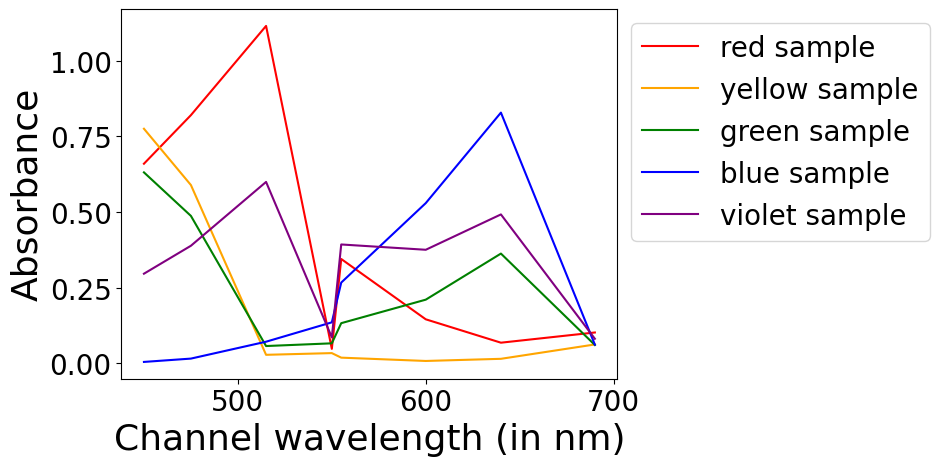

In [ ]:
df = loadFile('Abs/jehad.csv')
print(df)
to_plot = {}

for color in df.columns[1:]:
  spectrum = df[color]
  # to_plot[f'{color_names[color]} sample'] = spectrum

  plt.plot(wavelengths, spectrum, label=f'{color_names[color]} sample', color=color_shade[color])

plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=lgnd_label_size)
plt.xlabel("Channel wavelength (in nm)", fontsize=axis_label_size)
plt.ylabel("Absorbance", fontsize=axis_label_size)
plt.tick_params(axis='x', labelsize=tick_label_size)
plt.tick_params(axis='y', labelsize=tick_label_size)
# plotSpectrum(to_plot, '')

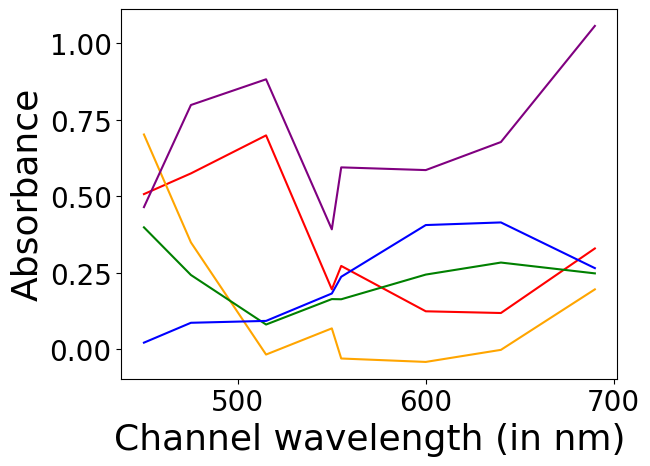

In [ ]:
for color in colors:
  fp = "/content/drive/MyDrive/CoE 199 (2s2425)/AS7343 Calibration/abs_per_color/"
  df = pd.read_csv(f'{fp}T_uncalib_{color}.csv')
  # spectrum = [fmean(df.iloc[6:12,i]) for i in range(1,9)]
  spectrum = df.iloc[6,1:9]
  plt.plot(wavelengths, spectrum, label=f'{color_names[color]} sample', color=color_shade[color])

# plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=lgnd_label_size)
plt.xlabel("Channel wavelength (in nm)", fontsize=axis_label_size)
plt.ylabel("Absorbance", fontsize=axis_label_size)
plt.tick_params(axis='x', labelsize=tick_label_size)
plt.tick_params(axis='y', labelsize=tick_label_size)

# Just Plots (SKIP)

This is just for figuring out which data is which... Ideally plot 5 spectra at a time from our data and MSI's data, and then match the 5, label/rename accordingly, then move to next 5 until all of our samples' spectrum have a matching spectrum with MSI.

In [ ]:
# fetches list of files from each folder
# re-run this every time you rename or delete a file from the MSI Reference folder
refs_fn_list = fetch_filelist()

for species in species_list:
  idx = species_list.index(species)
  length = len(refs_fn_list[idx])
  if length <= 22:
    done = "(DONE)"
  else:
    done = ""

  print(f'{species}: {length} files {done}')

chlo1: 21 files (DONE)
diat1: 22 files (DONE)
dino1: 21 files (DONE)
dino2: 21 files (DONE)
dino3: 22 files (DONE)


The next section is just file cleanup. Original MSI spectrometer readings had the first 11 lines of the CSV file as header information. This code block is simply to remove those first 11 lines. No need to run again. Nothing bad will happen if accidentally run again tho

In [ ]:
# I placed a guard condition (curr_ref.columns[0] == "WaveLength") to avoid
# redundant execution. If the ff. is true, that means we had to skip 11 lines
# to get to the true column header. So we have to go and remove those first 11
# lines. On the contrary, if this is false then we already removed the first 11
# lines. No need to remove another 11 lines

for ls in refs_fn_list:
  for i in range(len(ls)):
    curr_file = loadFile(ls[i], skip_rows=11) # get the file, skipping 11 rows
    curr_file = curr_file.drop(curr_file.columns[2], axis=1)

    if (curr_file.columns[0] == "WaveLength"): # guard
      curr_file.to_csv(global_fp + ls[i])

This is the part you actually use for plotting :))

   wavelength      0      2      4      6      8     10     12     14     16  \
0         450  48532  47808  46420  46322  45995  45778  45421  45841  45055   
1         475  36451  35686  34763  34527  34357  34211  33908  34023  33452   
2         515  47326  46448  45472  45239  45089  44961  44658  44854  44230   
3         550  16264  15896  15462  15337  15302  15235  15079  15140  14884   
4         555  64607  63149  61725  61628  61398  61140  60653  61227  60269   

   ...     30     35     40     45     50     60     70     80     90    100  
0  ...  44035  44416  44537  44596  43633  43041  41641  41650  40482  39343  
1  ...  32496  32929  32729  32734  32444  31589  30753  30367  29611  28837  
2  ...  43129  43646  43514  43509  43212  42308  41398  40973  40133  39373  
3  ...  14416  14603  14528  14500  14370  13956  13606  13333  13062  12689  
4  ...  58926  59412  58710  59861  58917  58025  56483  56374  55015  53883  

[5 rows x 23 columns]


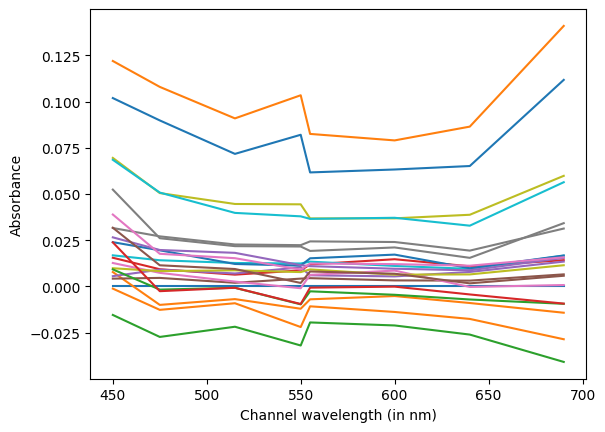

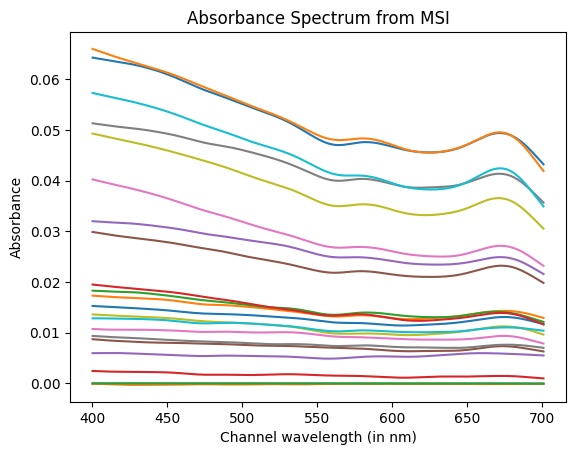

In [ ]:
percents = loadFile('Raw/'+sensor_fn_list[0]).columns[1:]
print(loadFile('Raw/'+sensor_fn_list[0]).head())

# which species are we working with?
species = "dino3" # input one of the five in species_list
species_idx = species_list.index(species) # get the index

# set the index range of what you want to plot
start = 0
stop = 22 # MAX = 22

msi_start = 0
msi_stop = 22 # MAX varies depending on species

# PLOT OUR DATA
spectrum_as7343 = loadFile('Abs/'+sensor_fn_list[species_idx])
cols = spectrum_as7343.columns[2:] # exclude first 2 cols
sensor_data = {}

for i in range(start, stop):
  spectrum = spectrum_as7343[cols[i]]
  sensor_data[f'{percents[i]}%'] = spectrum

plotSpectrum(sensor_data, "")

# PLOT MSI'S DATA
msi_file_list = refs_fn_list[species_idx]
msi_data = {}

for i in range(msi_start, msi_stop):
  df = loadFile(msi_file_list[i])
  spectrum = df['Abs.']
  wavelengths = df["WaveLength"]
  fn = msi_file_list[i][20:-4]
  msi_data[fn] = spectrum

plotSpectrumMSI(msi_data, wavelengths, 'Absorbance Spectrum from MSI')

# Compiling Refs (SKIP)
This section generates a file containing the corresponding readings from MSI. NOTE: Contains ONLY the reference readings, not paired up with the sensor readings

In [ ]:
refs_idx = {"450": 108, "475": 163, "515": 252, "550": 331, "555": 342, "600": 446, "640": 540, "690": 659}

refs_fn_list = fetch_filelist()

for species in species_list:
  idx = species_list.index(species)
  ls = refs_fn_list[idx]
  all_ref_df = pd.DataFrame(np.array([list(refs_idx.keys())]).reshape(-1,1), columns=['wavelength'])

  # add the blank (0% sample)
  blank_df = pd.DataFrame(np.array([[0.0]*8]).reshape(-1,1), columns=['0'], dtype='float32')
  all_ref_df = pd.concat([all_ref_df, blank_df], axis=1)

  if (len(ls) == 22):
    ls = ls[1:] # exclude 0% if it exists

  for file in ls: # each file is a concentration
    file_idx = ls.index(file)
    ref_df = loadFile(file)

    # build the spectrum
    spectrum = np.array([[]])
    for row in refs_idx.values(): # get each channel
      val = np.array([[ref_df['Abs.'][row]]], dtype='float32')
      spectrum = np.concat((spectrum, val), axis=1)

    # we now have a 1-col dataframe corresponding to 1 concentration
    spectrum_df = pd.DataFrame(spectrum.reshape(-1,1), columns=[percents[file_idx+1]])
    # append that to overall df
    all_ref_df = pd.concat([all_ref_df, spectrum_df], axis=1)

  # print(all_ref_df)
  # save as a csv
  fp = global_fp + "MSI Reference/" + species + "_ref.csv"
  all_ref_df.to_csv(fp, index=False)


Compile into single file.

In [ ]:
save_to_csv = False
exclude_blanks = True

# set the index of STarting CONCentration
if (exclude_blanks):
  st_conc = 1
else:
  st_conc = 0

reps = 10
n_conc = 22
n_species = 5

n_per_species = reps*(n_conc-st_conc)
n_TOTAL = reps*(n_conc-st_conc)*n_species

all_data_df = pd.DataFrame([[]]*n_TOTAL)
percents_tens = [val for val in percents[st_conc:] for _ in range(reps)]
row_labels = np.concat((percents_tens, percents_tens, percents_tens, percents_tens, percents_tens), axis=0)
all_data_df = pd.DataFrame(row_labels, columns=['percent'])


for ch in ch_str:
  ch_idx = ch_str.index(ch)
  ch_data_np = np.array([]).reshape(-1,1)

  for species in species_list:
    species_idx = species_list.index(species)

    fp = f'MSI Reference/{species}_ref.csv'
    species_df = loadFile(fp)
    data = np.array(species_df.iloc[ch_idx, 2:])
    data = [val for val in data for _ in range(reps)]
    data = np.array(data).reshape(-1,1)
    ch_data_np = np.concat((ch_data_np, data), axis=0)

  ch_data = pd.DataFrame(ch_data_np, columns=[f'{ch}nm'])
  all_data_df = pd.concat([all_data_df, ch_data], axis=1)

# add the labels for func group and species
group_labels = np.array([]).reshape(-1,1)
species_labels = np.array([]).reshape(-1,1)

for species in species_list:
  group_labels = np.concat((group_labels, np.array([species_groups[species]]*n_per_species).reshape(-1,1)), axis=0)
  species_labels = np.concat((species_labels, np.array([species_names[species]]*n_per_species).reshape(-1,1)), axis=0)

group_labels_df = pd.DataFrame(group_labels, columns=['group'])
species_labels_df = pd.DataFrame(species_labels, columns=['species'])

all_data_df = pd.concat([all_data_df, group_labels_df, species_labels_df], axis=1)
all_data_df['group'] = pd.Categorical(all_data_df['group']).codes

if (save_to_csv):
  fp = f'{global_fp}/MSI Reference/ALL_REFS.csv'
  all_data_df.to_csv(fp, index=False)

print(all_data_df.shape)
print(all_data_df.iloc[1040:1050,:])

(1050, 11)
      percent     450nm   475nm     515nm     550nm     555nm     600nm  \
1040      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1041      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1042      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1043      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1044      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1045      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1046      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1047      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1048      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   
1049      100  0.061334  0.0584  0.053755  0.049033  0.048495  0.047046   

         640nm     690nm  group         species  
1040  0.046153  0.046019      2  s. zambalensis  
1041  0.046153  0.046019      2  s. zambalensis  
1042  0.04615

# AS7343 vs MSI Readings

This section pairs up the sensor data with the reference readings from MSI **for each channel**. Optionally, save as .csv file.

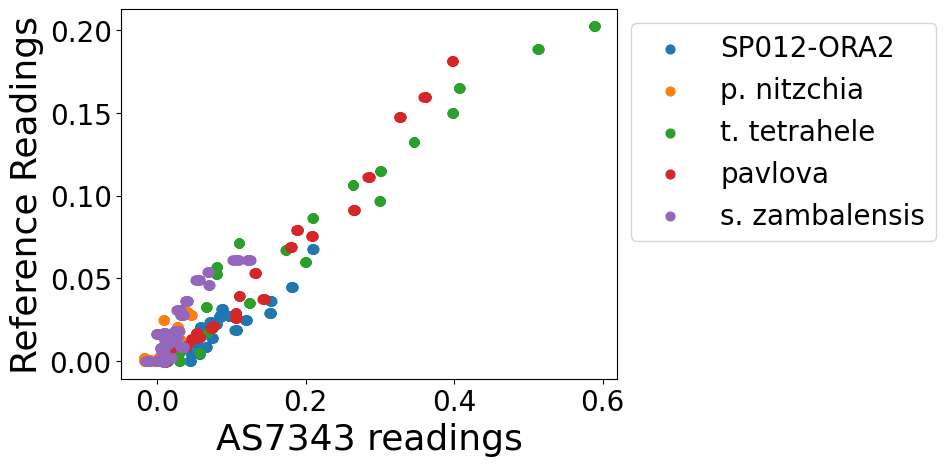

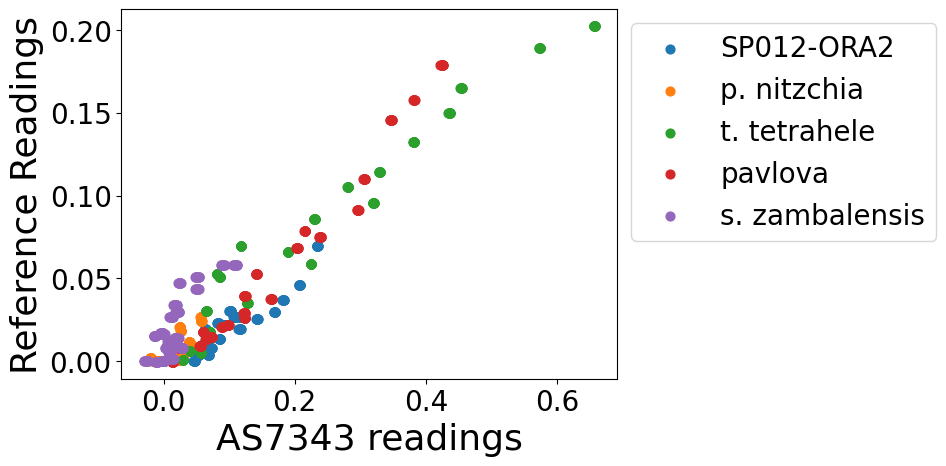

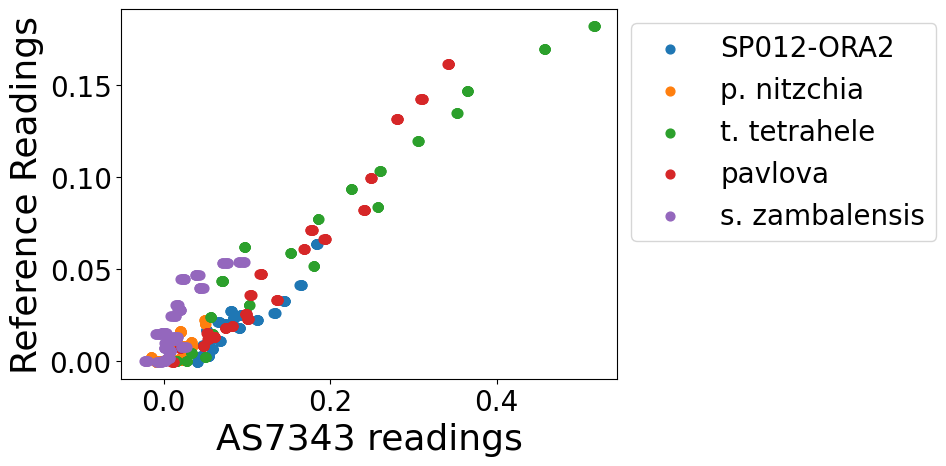

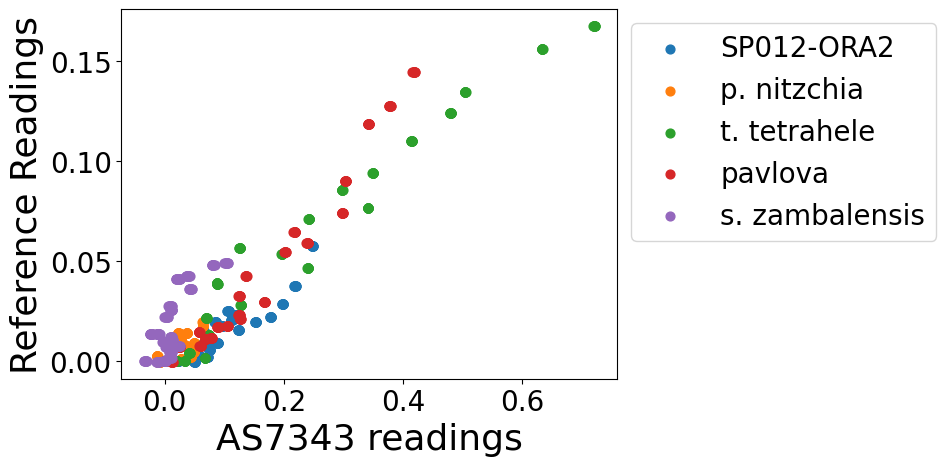

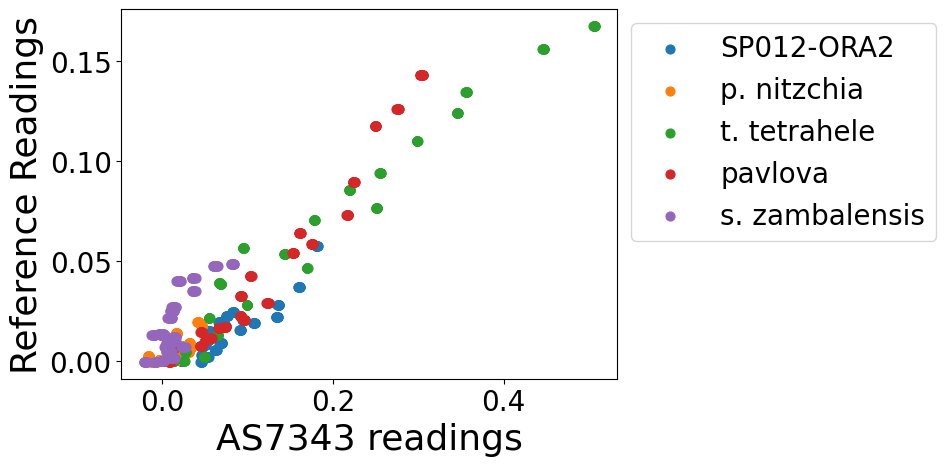

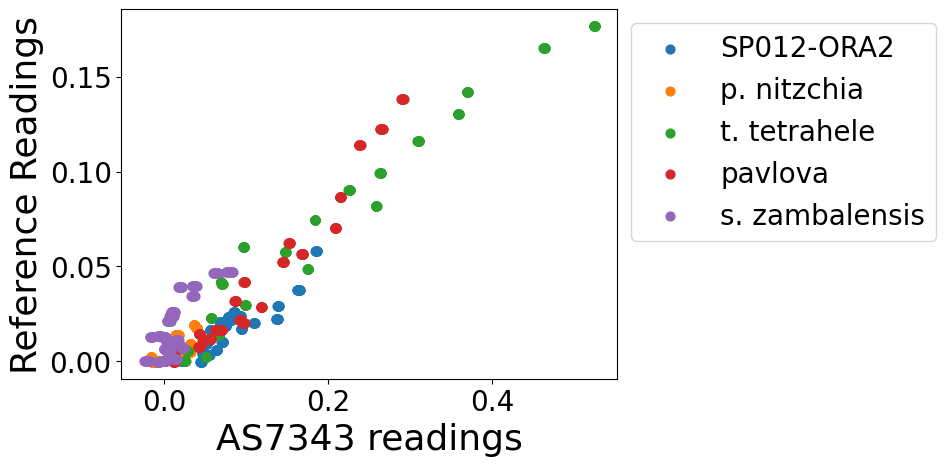

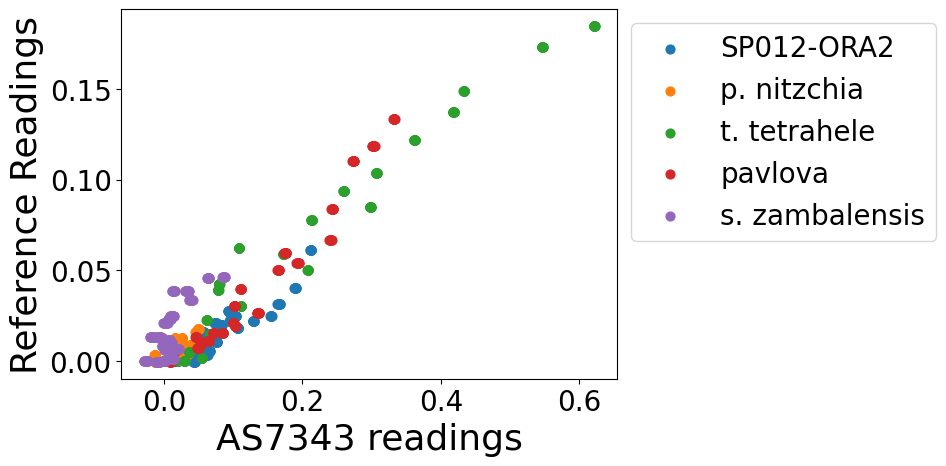

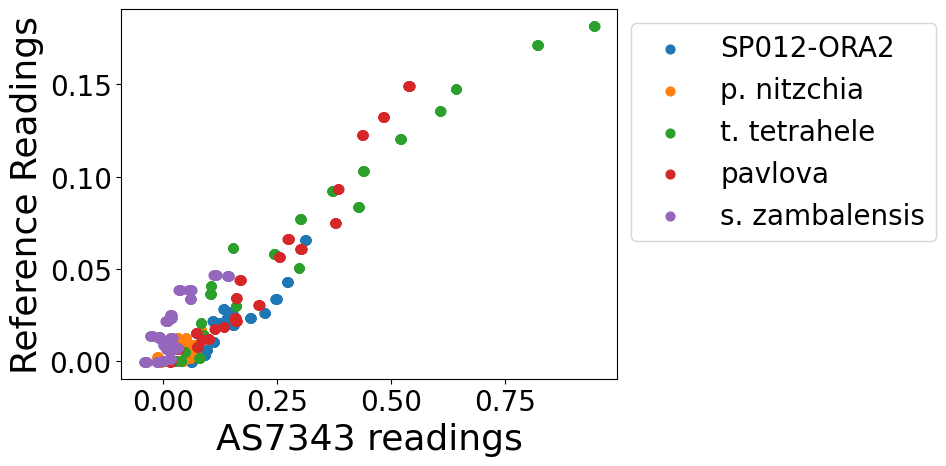

In [ ]:
save_per_ch_csv = False
plot_scatter = True

refs_idx = {"450": 108, "475": 163, "515": 252, "550": 331, "555": 342, "600": 446, "640": 540, "690": 659}

for i in range(8): # for each channel
  channel_name = list(refs_idx.keys())[i]

  percents_tens = [val for val in percents for _ in range(1)]
  row_labels = np.concat((percents_tens, percents_tens, percents_tens, percents_tens, percents_tens), axis=0)

  # start with empty numpy array because pd dataframes cant be concatenated when empty
  MSI_data = np.array([])
  AS7343_data = np.array([])
  group_label = np.array([])
  species_label = np.array([])

  for species in species_list:
    species_idx = species_list.index(species)

    ref_fp = 'MSI Reference/' + species + '_ref.csv'
    as7343_fp = 'Abs/Reps/' + sensor_fn_list[species_idx]
    ref_df = loadFile(ref_fp)
    as7343_df = loadFile(as7343_fp)
    y = ref_df.iloc[i,1:] # MSI reference
    y = np.array([val for val in y for _ in range(10)]) # duplicate 10 times
    X = as7343_df.iloc[i,1:] # sensor data

    if (save_per_ch_csv):
      MSI_data = np.concat((MSI_data, y), axis=0)
      AS7343_data = np.concat((AS7343_data, X.to_numpy()), axis=0)
      group_label = np.concat((group_label, np.array([species_groups[species]]*220)), axis=0)
      species_label = np.concat((species_label, np.array([species_names[species]]*220)), axis=0)

    if (plot_scatter):
      plt_label = f'{species_names[species]}'
      plt.scatter(X, y, label=plt_label, s=40.0)

  if (save_per_ch_csv):
    overall_np = np.concat(
        (row_labels.reshape(-1,1),
         MSI_data.reshape(-1,1),
         AS7343_data.reshape(-1,1),
         group_label.reshape(-1,1),
         species_label.reshape(-1,1)),
        axis=1)

    overall_df = pd.DataFrame(overall_np, columns=['percent', 'MSI_ref', 'AS7343', 'group', 'species'])

    fp = f'{global_fp}per_ch/{channel_name}nm.csv'
    overall_df.to_csv(fp, index=False)

  if (plot_scatter):
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=lgnd_label_size)
    plt.xlabel("AS7343 readings", fontsize=axis_label_size)
    plt.ylabel("Reference Readings", fontsize=axis_label_size)
    plt.tick_params(axis='x', labelsize=tick_label_size)
    plt.tick_params(axis='y', labelsize=tick_label_size)
    # plt.title(f"{channel_name}nm Scatter Plot")
    plt.show()

# Compile ALL Uncalib Data

In [ ]:
reps = 10
n_conc = 22

save_to_csv = True
exclude_blanks = True

# set the index of STarting CONCentration
if (exclude_blanks):
  st_conc = 1
else:
  st_conc = 0

n_per_species = reps*(n_conc-st_conc)
n_TOTAL = reps*(n_conc-st_conc)*n_species

all_data_df = pd.DataFrame([[]]*n_TOTAL)
percents_tens = [val for val in percents[st_conc:] for _ in range(reps)]
row_labels = np.concat((percents_tens, percents_tens, percents_tens, percents_tens, percents_tens), axis=0)
all_data_df = pd.DataFrame(row_labels, columns=['percent'])


for ch in ch_str:
  ch_idx = ch_str.index(ch)
  ch_data_np = np.array([]).reshape(-1,1)

  for species in species_list:
    species_idx = species_list.index(species)
    species_fn = sensor_fn_list[species_idx]

    fp = f'Abs/Reps/{species_fn}'
    species_df = loadFile(fp)
    offset = reps*st_conc
    data = np.array(species_df.iloc[ch_idx, 1+offset:]).reshape(-1,1)
    ch_data_np = np.concat((ch_data_np, data), axis=0)

  ch_data = pd.DataFrame(ch_data_np, columns=[f'{ch}nm'])
  all_data_df = pd.concat([all_data_df, ch_data], axis=1)

# add the labels for func group and species
group_labels = np.array([]).reshape(-1,1)
species_labels = np.array([]).reshape(-1,1)

for species in species_list:
  group_labels = np.concat((group_labels, np.array([species_groups[species]]*n_per_species).reshape(-1,1)), axis=0)
  species_labels = np.concat((species_labels, np.array([species_names[species]]*n_per_species).reshape(-1,1)), axis=0)

group_labels_df = pd.DataFrame(group_labels, columns=['group'])
species_labels_df = pd.DataFrame(species_labels, columns=['species'])

all_data_df = pd.concat([all_data_df, group_labels_df, species_labels_df], axis=1)

if (save_to_csv):
  fp = f'{global_fp}/Abs/ALL_DATA.csv'
  all_data_df.to_csv(fp, index=False)

print(all_data_df.shape)
print(all_data_df)

(1050, 11)
      percent     450nm     475nm     515nm     550nm     555nm     600nm  \
0           2  0.014249  0.020574  0.018450  0.022321  0.021977  0.021630   
1           2  0.015442  0.022088  0.018170  0.023769  0.023166  0.021392   
2           2  0.015107  0.020518  0.020022  0.022761  0.021629  0.022084   
3           2  0.014333  0.022004  0.018385  0.022509  0.022405  0.023037   
4           2  0.014898  0.020854  0.019915  0.022069  0.022056  0.021478   
...       ...       ...       ...       ...       ...       ...       ...   
1045      100  0.123018  0.110589  0.094238  0.104257  0.082878  0.080459   
1046      100  0.123881  0.110781  0.094672  0.104691  0.083334  0.081084   
1047      100  0.123976  0.111261  0.096096  0.105342  0.083896  0.082336   
1048      100  0.124552  0.111742  0.096217  0.105848  0.083966  0.083299   
1049      100  0.125655  0.111966  0.097208  0.106862  0.084493  0.083589   

         640nm     690nm           group         species  
0    

# Prepare Data For STM

In [ ]:
save_to_csv = False

all_df = loadFile('Abs/ALL_DATA.csv')
ref_df = pd.read_csv(f'{global_fp}MSI Reference/ALL_REFS.csv')

y_all = pd.Categorical(all_df['group']).codes

# create stratos based on group AND concentration
group_label = [str(grp) for grp in all_df['group']]
prcnt_label = [str(percent) for percent in all_df['percent'] ]
stratos = [group_label[i] + '_' + prcnt_label[i] for i in range(len(group_label))]

X_all = ref_df.drop(['species'], axis=1).copy()
# X_all['group'] = pd.Categorical(all_df['group']).codes
# .astype('float32')

test_size = 0.3 # keep this multiples of 0.1
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=test_size, random_state=42,
    stratify=stratos
    )

# save test data as csv
if (save_to_csv):
  # y_test_df = pd.DataFrame(y_test.reshape(-1,1), columns=['group'], index=X_test.index)
  fp = f'{global_fp}/X_ref.csv'
  X_test.to_csv(fp, index=True, header=True)
  # fp = f'{global_fp}Abs/y_grp.csv'
  # y_test_df.to_csv(fp, index=False, header=False)

# Calibration

## Initializing Variables

In [ ]:
# container for trained models
calib_models = {}

# data extracted per channel
data_per_ch = {}

RMSE_calib = { "Baseline": [] }
r2_calib = { "Baseline": [] }

for channel in ch_str:
  df = loadFile(f'per_ch/{channel}nm.csv')
  data = createData(df)

  data_per_ch[f'{channel}nm'] = data

  sr2, smse = calcBaseline(df, False)
  RMSE_calib["Baseline"].append(smse.item())
  r2_calib["Baseline"].append(sr2)

stats r2: 0.92309 , intercept: 0.0015932141658153223 , r: 0.9607736781657167 , p: 5.566041271027654e-62 , stderr: 0.010274882751038132
  metrics r2: 0.34992
  rmse: 0.09478

stats r2: 0.90356 , intercept: 0.0014414286444265137 , r: 0.9505573335329565 , p: 1.1373570296513328e-56 , stderr: 0.010403147874854822
  metrics r2: 0.26527
  rmse: 0.11103

stats r2: 0.9031 , intercept: 0.0006612809669926112 , r: 0.9503152262499602 , p: 1.4711314553799644e-56 , stderr: 0.011756532274907755
  metrics r2: 0.33907
  rmse: 0.08413

stats r2: 0.88233 , intercept: 0.0016204430161558814 , r: 0.9393252669949164 , p: 5.326507179649152e-52 , stderr: 0.008852241916622788
  metrics r2: 0.09808
  rmse: 0.13123

stats r2: 0.89066 , intercept: 0.0008747472517875408 , r: 0.943748882246329 , p: 1.0058517945004192e-53 , stderr: 0.011877144366537442
  metrics r2: 0.30309
  rmse: 0.08264

stats r2: 0.89863 , intercept: 0.001020219743291858 , r: 0.9479621865600663 , p: 1.680985525445265e-55 , stderr: 0.01148626514419

## Training

### Per CH Models

In [ ]:
models_to_train = [
    LinearRegression(),
    xgb.XGBRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    KNeighborsRegressor(n_neighbors=5),]

for model in models_to_train:
  model_name = model.__class__.__name__
  calib_models[model_name] = []
  RMSE_calib[model_name] = []
  r2_calib[model_name] = []

  for channel in ch_str:
    data = data_per_ch[f'{channel}nm']

    x, y, sr2, smse, model = trainModel(clone(model), data, f'{channel}nm', False)
    calib_models[model_name].append(model)
    RMSE_calib[model_name].append(smse.item())
    r2_calib[model_name].append(sr2)

Performance Metrics: LinearRegression 450nm
  metrics r2: 0.91113
  rmse: 0.01372

Performance Metrics: LinearRegression 475nm
  metrics r2: 0.88176
  rmse: 0.01577

Performance Metrics: LinearRegression 515nm
  metrics r2: 0.87797
  rmse: 0.0144

Performance Metrics: LinearRegression 550nm
  metrics r2: 0.85511
  rmse: 0.01429

Performance Metrics: LinearRegression 555nm
  metrics r2: 0.86076
  rmse: 0.01395

Performance Metrics: LinearRegression 600nm
  metrics r2: 0.8756
  rmse: 0.01344

Performance Metrics: LinearRegression 640nm
  metrics r2: 0.88375
  rmse: 0.01324

Performance Metrics: LinearRegression 690nm
  metrics r2: 0.89302
  rmse: 0.01316

Performance Metrics: XGBRegressor 450nm
  metrics r2: 0.87881
  rmse: 0.01602

Performance Metrics: XGBRegressor 475nm
  metrics r2: 0.79628
  rmse: 0.0207

Performance Metrics: XGBRegressor 515nm
  metrics r2: 0.78229
  rmse: 0.01924

Performance Metrics: XGBRegressor 550nm
  metrics r2: 0.75941
  rmse: 0.01841

Performance Metrics: XG

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 475nm
  metrics r2: 0.80381
  rmse: 0.02032

Performance Metrics: RandomForestRegressor 515nm
  metrics r2: 0.80493
  rmse: 0.01821



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 550nm
  metrics r2: 0.77559
  rmse: 0.01778

Performance Metrics: RandomForestRegressor 555nm
  metrics r2: 0.82742
  rmse: 0.01553



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 600nm
  metrics r2: 0.84769
  rmse: 0.01487

Performance Metrics: RandomForestRegressor 640nm
  metrics r2: 0.8106
  rmse: 0.0169



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor 690nm
  metrics r2: 0.81042
  rmse: 0.01751

Performance Metrics: KNeighborsRegressor 450nm
  metrics r2: 0.87093
  rmse: 0.01653

Performance Metrics: KNeighborsRegressor 475nm
  metrics r2: 0.84626
  rmse: 0.01798

Performance Metrics: KNeighborsRegressor 515nm
  metrics r2: 0.81786
  rmse: 0.0176

Performance Metrics: KNeighborsRegressor 550nm
  metrics r2: 0.8151
  rmse: 0.01614

Performance Metrics: KNeighborsRegressor 555nm
  metrics r2: 0.83681
  rmse: 0.01511

Performance Metrics: KNeighborsRegressor 600nm
  metrics r2: 0.84359
  rmse: 0.01507

Performance Metrics: KNeighborsRegressor 640nm
  metrics r2: 0.84282
  rmse: 0.0154

Performance Metrics: KNeighborsRegressor 690nm
  metrics r2: 0.8394
  rmse: 0.01612



### General Model

In [ ]:
models_to_train = [
    LinearRegression(),
    xgb.XGBRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    KNeighborsRegressor(n_neighbors=5),]

np_arr = np.array([[],[]]).reshape(-1,2)
all_data_df = pd.DataFrame(np_arr, columns=['MSI_ref', 'AS7343'])
for channel in ch_str:
  df = loadFile(f'per_ch/{channel}nm.csv').drop(['percent', 'group', 'species'], axis=1)
  all_data_df = pd.concat([all_data_df, df], axis=0)

print(all_data_df)

sr2, smse = calcBaseline(all_data_df, False)
RMSE_calib["Baseline"].append(smse.item())
r2_calib["Baseline"].append(sr2)

for model in models_to_train:
  model_name = model.__class__.__name__

  data = createData(all_data_df)

  x, y, sr2, smse, model = trainModel(clone(model), data, 'General Model', False)
  calib_models[model_name].append(model)
  RMSE_calib[model_name].append(smse.item())
  r2_calib[model_name].append(sr2)

  # calculate per channel metrics of the general model
  RMSE_calib[model_name + 'Gen'] = []
  r2_calib[model_name + 'Gen'] = []

  for channel in ch_str:
    data = data_per_ch[f'{channel}nm']
    y_pred = model.predict(data['X_test'])

    sr2 = round(r2_score(data['y_test'], y_pred), 5)
    smse = round(np.sqrt(mse(data['y_test'], y_pred)), 5)

    RMSE_calib[model_name + 'Gen'].append(smse.item())
    r2_calib[model_name + 'Gen'].append(sr2)

      MSI_ref    AS7343
0    0.000000  0.000000
1    0.000857  0.015030
2    0.000253  0.044493
3    0.004165  0.046606
4    0.010443  0.053691
..        ...       ...
105  0.038755  0.034216
106  0.033689  0.059804
107  0.038928  0.056355
108  0.046636  0.111698
109  0.046019  0.140875

[880 rows x 2 columns]
stats r2: 0.84637 , intercept: 0.002833090187247894 , r: 0.9199852263027806 , p: 0.0 , stderr: 0.004223745595550015
  metrics r2: 0.21359
  rmse: 0.11217

Performance Metrics: LinearRegression General Model
  metrics r2: 0.83041
  rmse: 0.01598

Performance Metrics: XGBRegressor General Model
  metrics r2: 0.81426
  rmse: 0.01672



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance Metrics: RandomForestRegressor General Model
  metrics r2: 0.8004
  rmse: 0.01733

Performance Metrics: KNeighborsRegressor General Model
  metrics r2: 0.83936
  rmse: 0.01555



## Performance

### Print Results

In [ ]:
print("RMSE Results")
for model in RMSE_calib.keys():
    # arr = []
    # for RMSE in RMSE_calib[model]:
    #     arr.append(RMSE)
    print(model[:8] + f':  {RMSE_calib[model]}')

print("\nR2 Scores")
for model in r2_calib.keys():
    print(model[:8] + f':  {r2_calib[model]}')

RMSE Results
Baseline:  [0.09478, 0.11103, 0.08413, 0.13123, 0.08264, 0.08312, 0.10249, 0.17554, 0.11217]
LinearRe:  [0.01372, 0.01577, 0.0144, 0.01429, 0.01395, 0.01344, 0.01324, 0.01316, 0.01598]
XGBRegre:  [0.01602, 0.0207, 0.01924, 0.01841, 0.01942, 0.01657, 0.01628, 0.01814, 0.01672]
RandomFo:  [0.01505, 0.02032, 0.01821, 0.01778, 0.01553, 0.01487, 0.0169, 0.01751, 0.01733]
KNeighbo:  [0.01653, 0.01798, 0.0176, 0.01614, 0.01511, 0.01507, 0.0154, 0.01612, 0.01555]
LinearRe:  [0.01693, 0.01612, 0.01659, 0.0176, 0.01477, 0.01455, 0.01312, 0.02576]
XGBRegre:  [0.01351, 0.0144, 0.01327, 0.01441, 0.01239, 0.01264, 0.00993, 0.01882]
RandomFo:  [0.00773, 0.01256, 0.01305, 0.01284, 0.01024, 0.01147, 0.00669, 0.0126]
KNeighbo:  [0.01418, 0.01649, 0.01333, 0.01563, 0.01227, 0.01295, 0.0101, 0.02095]

R2 Scores
Baseline:  [0.34992, 0.26527, 0.33907, 0.09808, 0.30309, 0.32175, 0.24469, 0.00713, 0.21359]
LinearRe:  [0.91113, 0.88176, 0.87797, 0.85511, 0.86076, 0.8756, 0.88375, 0.89302, 0.83041]

### Plot Results

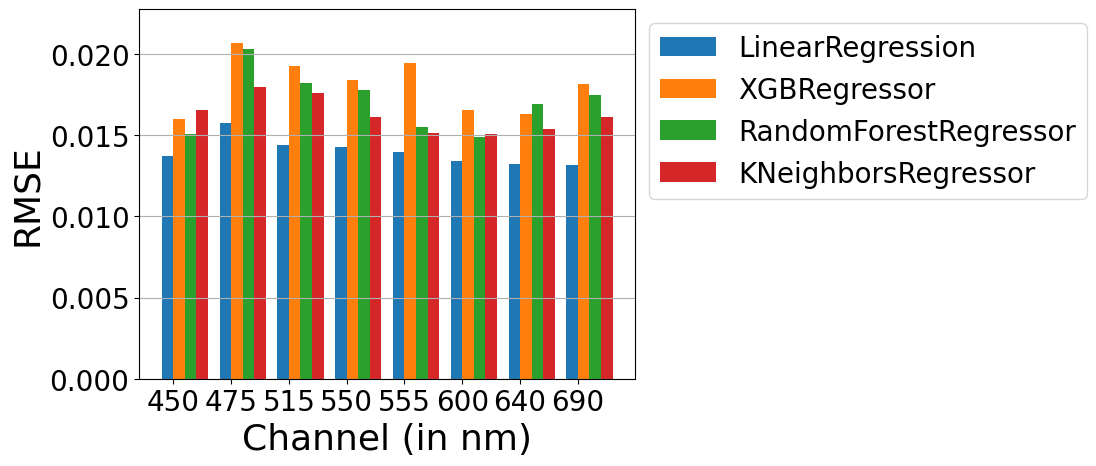

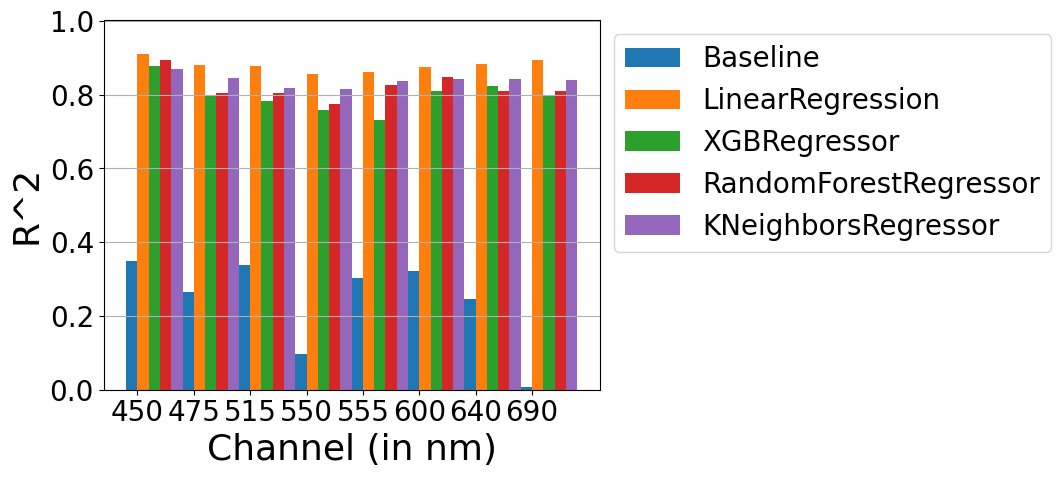

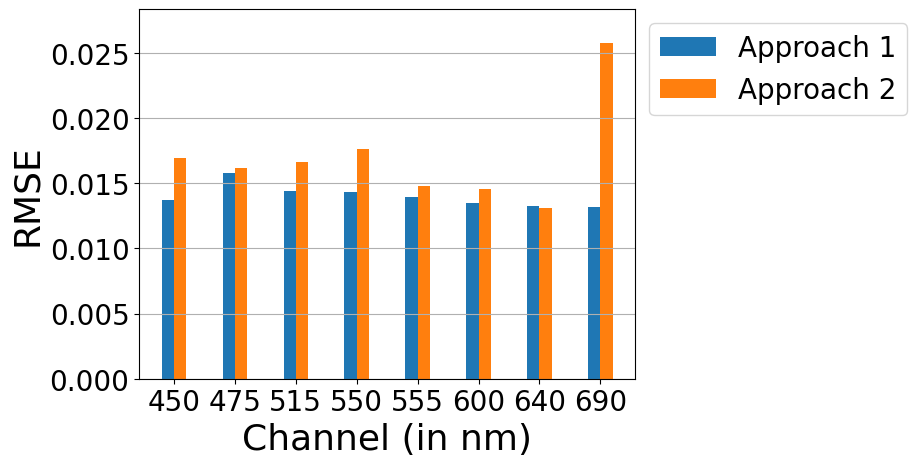

In [ ]:
plotMetric(RMSE_calib, 'RMSE', exclude_baseline=True)
plotMetric(r2_calib, 'R^2')

plotMetric({'Approach 1': RMSE_calib['LinearRegression'],
            'Approach 2': RMSE_calib['LinearRegressionGen']}, 'RMSE', exclude_baseline=False)

## See Parameters

In [ ]:
plotCalibrationModels = True

print('channel|\tscikit-learn')
print(' (nm)  |  slope (m)  y-inter (b)')
print('-------+-------------------------+')

for model in calib_models['LinearRegression']:
  # get parameters from scikit models
  skl_m = model.coef_[0][0].item()
  skl_b = model.intercept_.item()
  params = [np.array(model.coef_, dtype='float32'), np.array(model.intercept_, dtype='float32')]

  idx = list(calib_models['LinearRegression']).index(model)
  print(f'  {ch_str[idx]}  | {skl_m:10f} {skl_b:10f}')

if (plotCalibrationModels):
  for ch in ch_str:
    models_to_plot = []
    for mdl_name, models in calib_models.items():
      if mdl_name in ['LinearRegression', 'KNeighborsRegressor']:
        ch_idx = ch_str.index(ch)
        models_to_plot.append(models[ch_idx])

    ch_data = data_per_ch[f'{ch}nm']
    plotRegression(ch, models_to_plot, ch_data['X_all'], ch_data['y_all'])

channel|	scikit-learn
 (nm)  |  slope (m)  y-inter (b)
-------+-------------------------+
  450  |   0.372511   0.002005
  475  |   0.334817   0.001618
  515  |   0.378135   0.000691
  550  |   0.255320   0.001544
  555  |   0.357168   0.001024
  600  |   0.359794   0.001184
  640  |   0.317305   0.001094
  690  |   0.217606   0.000779


IndexError: list index out of range

# Export Models (CALIB)
This is specifically to export the Linear Regression model ONLY. will not work for the other models

In [ ]:
RMSE_calib['SKL-to-TF'] = []
r2_calib['SKL-to-TF'] = []

skl_to_tf_models = []

for ch_model in calib_models['LinearRegression']:
  ch = ch_str[calib_models['LinearRegression'].index(ch_model)]
  # get parameters from sklearn models
  # save to a single array to become weights for tf model
  params = [np.array(ch_model.coef_, dtype='float32'), np.array(ch_model.intercept_, dtype='float32')]

  # create tf model
  tf_model = tf.keras.models.Sequential()
  # add single layer
  tf_model.add(tf.keras.Input(shape=(1,)))
  tf_model.add(tf.keras.layers.Dense(input_shape=(1,), units=1, bias_initializer='zeros'))
  tf_model.compile(loss='mse')
  # set weights of that layer
  tf_model.layers[0].set_weights(params)

  # verify the models do the same prediction
  data = data_per_ch[f'{ch}nm']
  x_input = np.arange(0,1.01, 0.01).reshape(-1,1)
  print( np.all(tf_model.predict(x_input) == ch_model.predict(x_input)) )

  # save model
  skl_to_tf_models.append(tf_model)

  # start as keras file first
  fn = f'{global_fp}Calibration Models/keras/{ch}nm.keras'
  tf.keras.models.save_model(tf_model, fn)

  # from keras, export as tflite
  converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
  tflite_model = converter.convert()

  fn = f'{global_fp}Calibration Models/{ch}nm.tflite'
  with open(fn, "wb") as f:
    f.write(tflite_model)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
False
Saved artifact at '/tmp/tmpas1rdjnm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136834608120656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136835384621008: TensorSpec(shape=(), dtype=tf.resource, name=None)
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
False
Saved artifact at '/tmp/tmptotfkc5u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136835382857744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136835382854096: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

False
Saved artifact at '/tmp/tmppjoju3jb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136835382869072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136835382866192: TensorSpec(shape=(), dtype=tf.resource, name=None)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


False
Saved artifact at '/tmp/tmpspjwzfqc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136835382861392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136835382868688: TensorSpec(shape=(), dtype=tf.resource, name=None)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


False
Saved artifact at '/tmp/tmp8wq2t1ns'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136835382869840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834307769744: TensorSpec(shape=(), dtype=tf.resource, name=None)


# Apply Calibration

## Get Calibrated Spectrum

In [ ]:
save_to_csv = False

for file in sensor_fn_list:
  uncalib_df = loadFile(f'Abs/Reps/{file}')
  samples = uncalib_df.columns[1:]

  calib_df = pd.DataFrame(np.array(ch_int).reshape(-1,1), columns=['wavelength'])
  for sample in samples:
    spectrum = uncalib_df[sample].copy()
    calib_spectrum = calibrateSpectrum(spectrum, calib_models['LinearRegression'], form='df', column=sample)
    calib_df = pd.concat([calib_df, calib_spectrum], axis=1)

  if (save_to_csv):
    idx = sensor_fn_list.index(file)
    species = species_list[idx]

    fp = f'{global_fp}Calibrated/{species}_calib.csv'
    calib_df.to_csv(fp, index=False)

##  TODO: Plot Calibrated Spectrum

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]


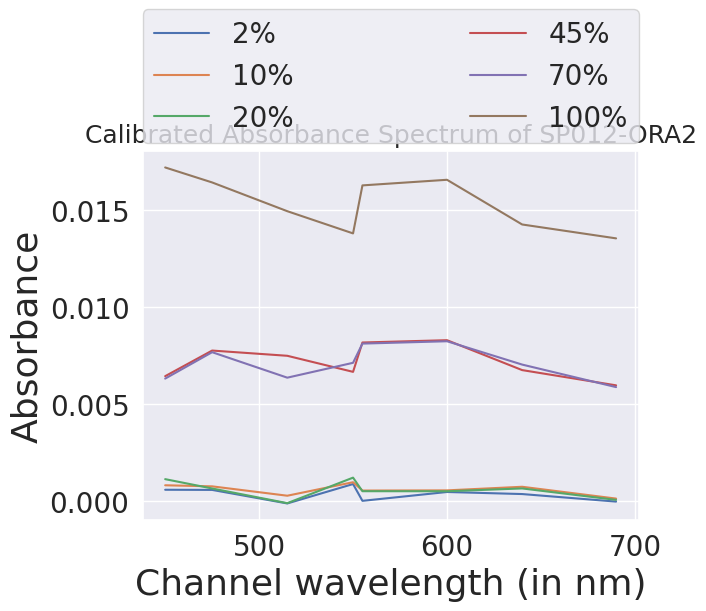

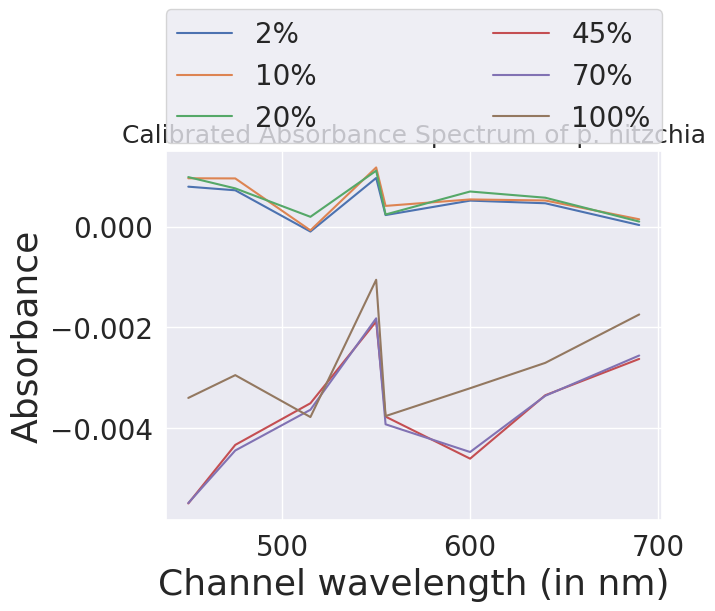

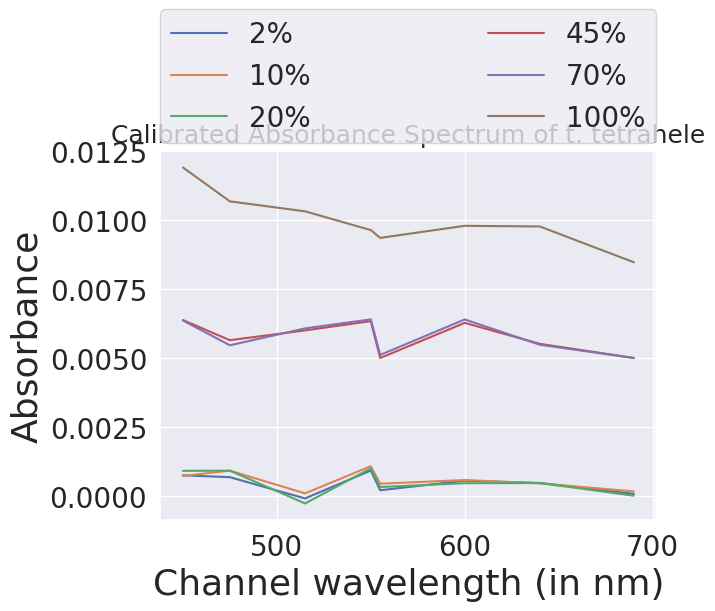

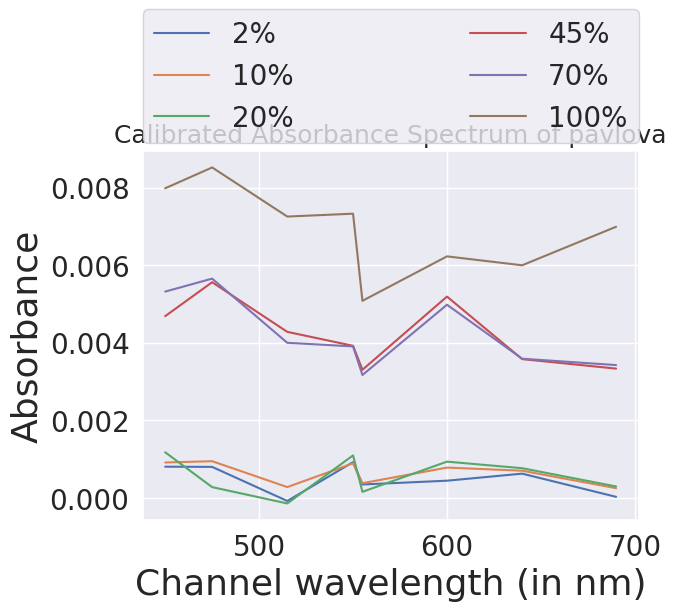

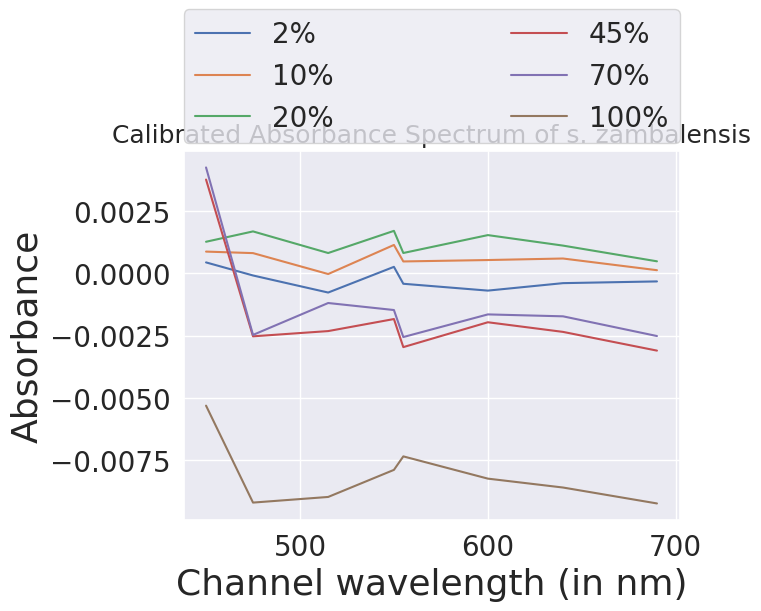

In [ ]:
print(percents)
for species in species_list:
  fn = f'Calibrated/{species}_calib.csv'
  df = loadFile(fn)
  cols = df.columns[1:] # exclude first column
  sensor_data = {}

  idxs = [0, 4, 9, 14, 17, 20]

  for i in idxs:
    spectrum = df[cols[i]]
    sensor_data[f'{percents[i]}%'] = spectrum

  plotSpectrum(sensor_data, f'Calibrated Absorbance Spectrum of {species_names[species]}')

# Compile ALL Calib Data

In [ ]:
save_to_csv = False
exclude_blanks = True

# set the index of STarting CONCentration
if (exclude_blanks):
  st_conc = 1
else:
  st_conc = 0

n_per_species = reps*(n_conc-st_conc)
n_TOTAL = reps*(n_conc-st_conc)*n_species

all_data_df = pd.DataFrame([[]]*n_TOTAL)
percents_tens = [val for val in percents[st_conc:] for _ in range(reps)]
row_labels = np.concat((percents_tens, percents_tens, percents_tens, percents_tens, percents_tens), axis=0)
all_data_df = pd.DataFrame(row_labels, columns=['percent'])


for ch in ch_str:
  ch_idx = ch_str.index(ch)
  ch_data_np = np.array([]).reshape(-1,1)

  for species in species_list:
    species_idx = species_list.index(species)

    fp = f'Calibrated/{species}_calib.csv'
    species_df = loadFile(fp)
    offset = reps*st_conc
    data = np.array(species_df.iloc[ch_idx, 1+offset:]).reshape(-1,1)
    ch_data_np = np.concat((ch_data_np, data), axis=0)

  ch_data = pd.DataFrame(ch_data_np, columns=[f'{ch}nm'])
  all_data_df = pd.concat([all_data_df, ch_data], axis=1)

# add the labels for func group and species
group_labels = np.array([]).reshape(-1,1)
species_labels = np.array([]).reshape(-1,1)

for species in species_list:
  group_labels = np.concat((group_labels, np.array([species_groups[species]]*n_per_species).reshape(-1,1)), axis=0)
  species_labels = np.concat((species_labels, np.array([species_names[species]]*n_per_species).reshape(-1,1)), axis=0)

group_labels_df = pd.DataFrame(group_labels, columns=['group'])
species_labels_df = pd.DataFrame(species_labels, columns=['species'])

all_data_df = pd.concat([all_data_df, group_labels_df, species_labels_df], axis=1)

if (save_to_csv):
  fp = f'{global_fp}/Calibrated/ALL_DATA.csv'
  all_data_df.to_csv(fp, index=False)

print(all_data_df.shape)
print(all_data_df)

(1050, 11)
      percent     450nm     475nm     515nm     550nm     555nm     600nm  \
0           2  0.006203  0.007671  0.006943  0.006732  0.008151  0.008352   
1           2  0.006648  0.008177  0.006838  0.007101  0.008574  0.008267   
2           2  0.006523  0.007652  0.007536  0.006844  0.008027  0.008515   
3           2  0.006234  0.008149  0.006919  0.006780  0.008303  0.008856   
4           2  0.006445  0.007765  0.007495  0.006667  0.008179  0.008298   
...       ...       ...       ...       ...       ...       ...       ...   
1045      100  0.046788  0.037737  0.035492  0.027650  0.029835  0.029407   
1046      100  0.047109  0.037801  0.035655  0.027761  0.029998  0.029630   
1047      100  0.047145  0.037961  0.036192  0.027927  0.030198  0.030078   
1048      100  0.047360  0.038122  0.036237  0.028056  0.030223  0.030423   
1049      100  0.047771  0.038196  0.036611  0.028315  0.030410  0.030527   

         640nm     690nm           group         species  
0    

# Classification

## Prepare Data

In [ ]:
save_to_csv = False

all_df = loadFile('Calibrated/ALL_DATA.csv')

y_all = pd.Categorical(all_df['group']).codes

# create stratos based on group AND concentration
group_label = [str(grp) for grp in all_df['group']]
prcnt_label = [str(percent) for percent in all_df['percent'] ]
stratos = [group_label[i] + '_' + prcnt_label[i] for i in range(len(group_label))]

X_all = all_df.drop(['percent', 'group', 'species'], axis=1).copy().astype('float32')

test_size = 0.3 # keep this multiples of 0.1
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=test_size, random_state=42,
    stratify=stratos
    )

print(X_test)

# save test data as csv
if (save_to_csv):
  y_test_df = pd.DataFrame(y_test.reshape(-1,1), columns=['group'], index=X_test.index)
  fp = f'{global_fp}Calibrated/test.csv'
  X_test.to_csv(fp, index=False, header=False)
  fp = f'{global_fp}Calibrated/test_out.csv'
  y_test_df.to_csv(fp, index=False, header=False)

         450nm     475nm     515nm     550nm     555nm     600nm     640nm  \
928   0.009036  0.006372  0.005538  0.004457  0.005643  0.005548  0.003982   
622   0.220828  0.220169  0.195073  0.185185  0.180705  0.188663  0.196548   
22    0.018283  0.018679  0.016470  0.015472  0.016284  0.017815  0.016618   
851  -0.004915 -0.009001 -0.008599 -0.007747 -0.007192 -0.007863 -0.008436   
111   0.036936  0.039400  0.035080  0.031859  0.032620  0.033490  0.033151   
...        ...       ...       ...       ...       ...       ...       ...   
1023  0.026190  0.017310  0.014641  0.010388  0.012991  0.013136  0.010630   
535   0.075454  0.075995  0.067809  0.062493  0.060709  0.063036  0.066294   
240  -0.002805  0.001836  0.000416  0.003948 -0.001173 -0.000825  0.002323   
99    0.028043  0.028545  0.024906  0.022823  0.024411  0.024986  0.024499   
513   0.041990  0.040208  0.036671  0.033297  0.034149  0.035300  0.034947   

         690nm  
928   0.004059  
622   0.206549  
22    0.0162

## Training

In [ ]:
classification_models = {}

models_to_train = [
    xgb.XGBClassifier(objective='binary:logistic', seed=42, early_stopping_rounds=10, num_parallel_tree=1,
    eval_metric='auc'),
    RandomForestClassifier(random_state=42),
    SVC(random_state=42),
    KNeighborsClassifier(),]

# train xgb classifier seperately because it needs additional argument
model = models_to_train[0].fit(X_train, y_train, eval_set=[(X_test, y_test)])
name = model.__class__.__name__
classification_models[name] = model
print(f'Done training {name}')

for model in models_to_train[1:]:
  model.fit(X_train, y_train)
  name = model.__class__.__name__
  classification_models[name] = model
  print(f'Done training {name}')

[0]	validation_0-auc:0.97634
[1]	validation_0-auc:0.98793
[2]	validation_0-auc:0.98981
[3]	validation_0-auc:0.99109
[4]	validation_0-auc:0.99072
[5]	validation_0-auc:0.99145
[6]	validation_0-auc:0.99189
[7]	validation_0-auc:0.99215
[8]	validation_0-auc:0.99307
[9]	validation_0-auc:0.99329
[10]	validation_0-auc:0.99353
[11]	validation_0-auc:0.99369
[12]	validation_0-auc:0.99433
[13]	validation_0-auc:0.99497
[14]	validation_0-auc:0.99483
[15]	validation_0-auc:0.99466
[16]	validation_0-auc:0.99509
[17]	validation_0-auc:0.99507
[18]	validation_0-auc:0.99528
[19]	validation_0-auc:0.99555
[20]	validation_0-auc:0.99550
[21]	validation_0-auc:0.99601
[22]	validation_0-auc:0.99647
[23]	validation_0-auc:0.99654
[24]	validation_0-auc:0.99683
[25]	validation_0-auc:0.99716
[26]	validation_0-auc:0.99721
[27]	validation_0-auc:0.99740
[28]	validation_0-auc:0.99750
[29]	validation_0-auc:0.99765
[30]	validation_0-auc:0.99756
[31]	validation_0-auc:0.99764
[32]	validation_0-auc:0.99773
[33]	validation_0-au

## Performance

### Overall Performance


XGBClassifier


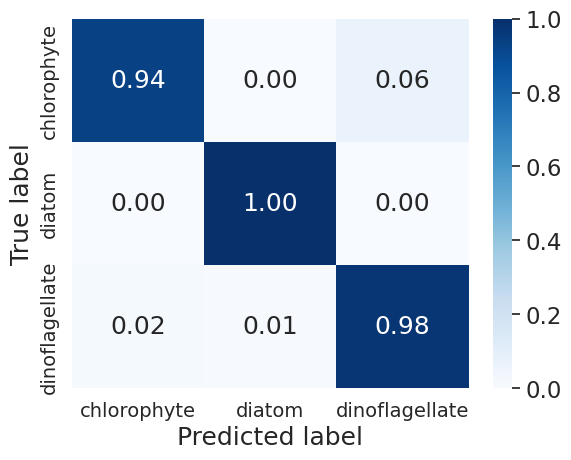


RandomForestClassifier


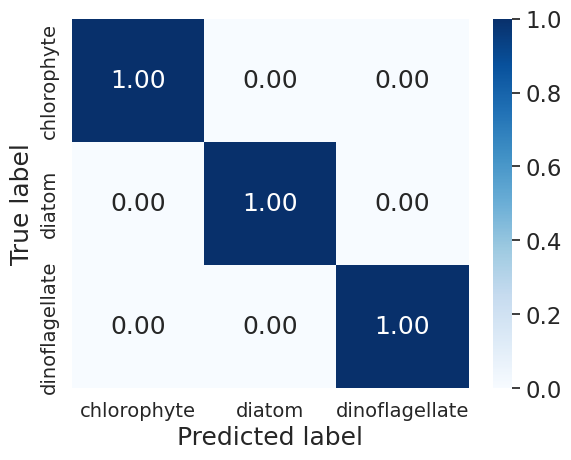


SVC


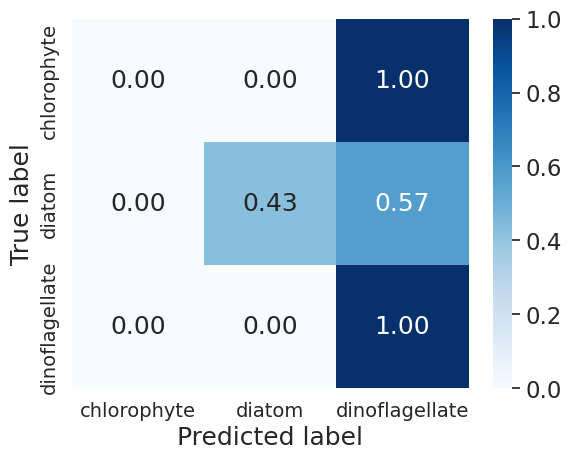


KNeighborsClassifier


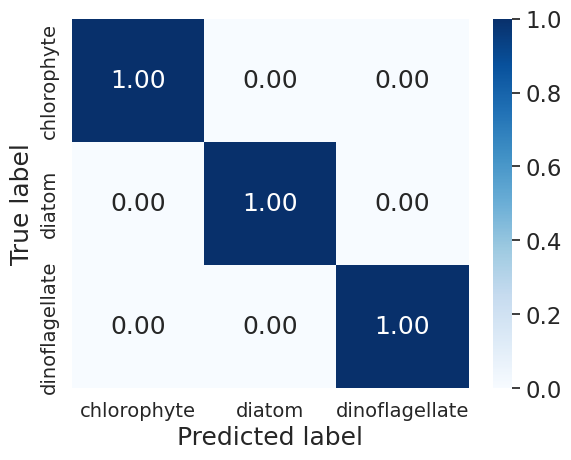

In [ ]:
for name, model in classification_models.items():
  model_name = model.__class__.__name__
  print('\n'+model_name)
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred, labels=[model.classes_], normalize='true')

  ax = plt.subplot()
  sns.heatmap(cm, annot=True, ax=ax, cmap="Blues", fmt=".2f");

  # Labels, title and ticks
  label_font = {'size':'18'}  # Adjust to fit
  ax.set_xlabel('Predicted label', fontdict=label_font);
  ax.set_ylabel('True label', fontdict=label_font);

  ax.tick_params(axis='both', which='major', labelsize=14)  # Adjust to fit
  ax.xaxis.set_ticklabels(['chlorophyte', 'diatom', 'dinoflagellate']);
  ax.yaxis.set_ticklabels(['chlorophyte', 'diatom', 'dinoflagellate']);
  plt.show()

  ## old method
  # disp = ConfusionMatrixDisplay(confusion_matrix=cm,
  #                               display_labels=['chlorophyte', 'diatom', 'dinoflagellate'])
  # disp.plot()
  # plt.title(f'{model_name} Confusion Matrix')
  # plt.show()

### Stratified Performance

In [ ]:
X_test_sorted = X_test.sort_index()
indices = X_test_sorted.index
# print(list(indices))

# for averaged data
# indices = X_test.index
# print(indices)
# label = [y_all[idx] for idx in list(indices)]

# for non-averaged data
st_conc=1
n_test = math.ceil(test_size*reps)
str_label = [species for species in list(species_groups.values()) for _ in range(n_test*(n_conc-st_conc))]
y_test_df = pd.DataFrame(str_label, columns=['group'], index=indices)
y_test_cat = pd.Categorical(y_test_df['group']).codes
# print(y_test_cat)

In [ ]:
# print(percents)
# classifier = classification_models['RandomForestClassifier']
# acc = []

# idxs = []

# for i in range(X_test_sorted.shape[0]):
#   X = X_test_sorted.iloc[i, :8]
#   y = label[i]

#   # print(X.name)
#   idxs.append(X.name)
#   y_pred = classifier.predict([X])

#   acc.append(int(y == y_pred))

# print()
# print([all_df['percent'][idx].item() for idx in idxs])
# print(acc)

In [ ]:
# print(percents)
classifier = classification_models['RandomForestClassifier']
acc = {}

for i in range(len(species_list)):

  acc[species_list[i]] = []
  for p in range(n_conc-st_conc):
    start = (i*(n_conc-st_conc)*n_test)+(p*n_test)
    end = start + n_test
    X = X_test_sorted.iloc[start:end, :8]
    y = y_test_cat[start:end]

    y_pred = classifier.predict(X)

    acc[species_list[i]].append(accuracy_score(y, y_pred))
  # print(acc[species_list[i]])

print(acc['chlo1'])
print(acc['diat1'])
acc['dino'] = [fmean([acc['dino1'][i], acc['dino2'][i], acc['dino3'][i]]) for i in range(n_conc-st_conc)]
print(acc['dino'])

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


# Export Models (CLF)

Export XGB

In [ ]:
name = 'XGBClassifier'
model = classification_models[name]

fp = f'{global_fp}/Classification Models/{name}.c'
with open(fp,'w') as file: # this DOES work
  code = m2c.export_to_c(model)
  file.write(code)

# onnx_model = onnxmltools.convert_xgboost(model, initial_types=[('spectrum', onnxmltools.convert.common.data_types.FloatTensorType([None, X_all.shape[1]]))], )

# # Save the ONNX model
# fp = f'{global_fp}/Classification Models/{name}.onnx'
# with open(fp, "wb") as f:
#   f.write(onnx_model.SerializeToString())

# model.save_model(global_fp + "/Classification Models/" + name + ".bin")

Export RF Classifier

In [ ]:
name = 'RandomForestClassifier'
model = classification_models[name]

initial_type = [ ('spectrum', FloatTensorType([None, X_all.shape[1]]) ) ]

onnx_model = convert_sklearn(model, initial_types=initial_type, options={type(model): {'zipmap':False}})

fp = f'{global_fp}/Classification Models/{name[:12]}.onnx'
# with open(fp, "wb") as f:
#   f.write( onnx_model.SerializeToString())

Export SVC

In [ ]:
name = 'SVC'
model = classification_models[name]

initial_type = [ ('spectrum', FloatTensorType([None, X_all.shape[1]]) ) ]

onnx_model = convert_sklearn(model, initial_types=initial_type, options={type(model): {'zipmap':False}})

fp = f'{global_fp}/Classification Models/{name}.onnx'
# with open(fp, "wb") as f:
#   f.write( onnx_model.SerializeToString())

Export KNeighbors

In [ ]:
name = 'KNeighborsClassifier'
model = classification_models[name]

initial_type = [ ('spectrum', FloatTensorType([None, X_all.shape[1]]) ) ]

# onnx_model = convert_sklearn(model, initial_types=initial_type
#                              , options={type(model): {'zipmap':False}}
#                              , black_op=['Scan']
#                              )

fp = f'{global_fp}/Classification Models/kNNClassifier.onnx'
with open(fp,'w') as file:
  code = m2c.export_to_c(model)
  file.write(code)

# with open(fp, "wb") as f:
#   f.write( onnx_model.SerializeToString())

NotImplementedError: Model 'sklearn_KNeighborsClassifier' is not supported

# Concentration Regression

## Prepare Data

In [ ]:
all_df = loadFile(f'Calibrated/ALL_DATA.csv')
# all_df.head()

code = pd.Categorical(all_df['group']).codes
all_df['group'] = pd.Categorical(code)
all_df['percent'] = all_df['percent'].astype('float32')
print(all_df.dtypes)

# create stratos based on group AND concentration
group_label = [str(grp) for grp in all_df['group']]
prcnt_label = [str(percent) for percent in all_df['percent'] ]
stratos = [group_label[i] + '_' + prcnt_label[i] for i in range(len(group_label))]

X_all = all_df.drop(['percent', 'species', 'group'], axis=1).copy()
y_all = all_df['percent']

test_size = 0.3 # keep this multiples of 0.1
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=test_size, random_state=42,
    stratify=stratos
    )

print(X_test.head())

# regr_ref = pd.concat([X_test, y_test], axis=1)
# regr_ref.to_csv(f'{global_fp}X_calib.csv', index=True)


percent     float32
450nm       float64
475nm       float64
515nm       float64
550nm       float64
555nm       float64
600nm       float64
640nm       float64
690nm       float64
group      category
species      object
dtype: object
        450nm     475nm     515nm     550nm     555nm     600nm     640nm  \
928  0.009036  0.006372  0.005538  0.004457  0.005643  0.005548  0.003982   
622  0.220828  0.220169  0.195073  0.185185  0.180705  0.188663  0.196548   
22   0.018283  0.018679  0.016470  0.015472  0.016284  0.017815  0.016618   
851 -0.004915 -0.009001 -0.008599 -0.007747 -0.007192 -0.007863 -0.008436   
111  0.036936  0.039400  0.035080  0.031859  0.032620  0.033490  0.033151   

        690nm  
928  0.004059  
622  0.206549  
22   0.016230  
851 -0.009240  
111  0.033289  


## Training

In [ ]:
# models to be trained
models = [xgb.XGBRegressor(random_state=42, enable_categorical=True),
          RandomForestRegressor(max_depth=3, max_features='sqrt', max_leaf_nodes=9, n_estimators=300, random_state=42),
          LinearRegression(),
          RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5),
          SVR(kernel='rbf', gamma=0.1, C=0.1, epsilon=0.01)
          ]

regr_models = {} # container for trained models
RMSE_regr = {}   # metrics
r2_regr = {}     # metrics
regr_data = {'X_test': X_test, 'y_test': y_test}

for model in models:
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  cn = model.__class__.__name__
  sr2 = round(r2_score(y_test, y_pred), 5)
  smse = round(np.sqrt(mse(y_test, y_pred)), 5)

  regr_models[cn] = model
  RMSE_regr[cn] = smse.item()
  r2_regr[cn] = sr2

model = regr_models['XGBRegressor']
y_pred = model.predict(regr_data['X_test'])
smse = round(np.sqrt(mse(y_test, y_pred)), 5)
print(smse)

4.36995


## Performance

In [ ]:
for key, val in RMSE_regr.items():
  print(f'{key}: {val}')

XGBRegressor: 4.36995
RandomForestRegressor: 20.05948
LinearRegression: 20.12448
RidgeCV: 23.09802
SVR: 30.64835


# Export Models (REGR)

## XGBoost

In [ ]:
model = regr_models['XGBRegressor']

fp = global_fp+'Concentration Models/regr_xgb2.c'
# with open(fp,'w') as file:
#   code = m2c.export_to_c(model)
#   file.write(code)

model.save_model(global_fp + "/Concentration Models/regr_xgb.bin")

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1116: UserWarning: [09:17:27] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


## Random Forest

In [ ]:
model = regr_models['RandomForestRegressor']

initial_type = [ ('spectrum', FloatTensorType([None, X_all.shape[1]]) ) ]

onnx_model = convert_sklearn(model, initial_types=initial_type, options={type(model): {}})

fp = f'{global_fp}/Concentration Models/regr_rfr2.onnx'
with open(fp, "wb") as f:
  f.write( onnx_model.SerializeToString())

## Linear Regression

In [ ]:
model = regr_models['LinearRegression']
coefs = model.coef_
intercept = model.intercept_
print(coefs)
print(intercept)

params = [np.array(coefs, dtype='float32').reshape(-1,1), np.array([intercept], dtype='float32')]

# create tf model
tf_model = tf.keras.models.Sequential()
# add single layer
tf_model.add(tf.keras.Input(shape=(X_all.shape[1],)))
tf_model.add(tf.keras.layers.Dense(input_shape=(X_all.shape[1],), units=1, bias_initializer='zeros'))
tf_model.compile(loss='mse')
# set weights of that layer
tf_model.layers[0].set_weights(params)

# export as tflite
fn = global_fp+'Concentration Models/regr_lin2.keras' # start as keras file first
tf.keras.models.save_model(tf_model, fn)

converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
tflite_model = converter.convert()

fn = global_fp+"Concentration Models/regr_lin2.tflite"
with open(fn, "wb") as f:
  f.write(tflite_model)

[ 3766.65141418 -2341.81966272  -893.63146792  1252.15527892
   -60.4292575  -4026.92129212  -479.78914943  2919.76707941
   -12.80437216]
35.68851812742756


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved artifact at '/tmp/tmprl2iw9bt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135811146676752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135811146677520: TensorSpec(shape=(), dtype=tf.resource, name=None)


# Comparison with STM32

## Retrieve Data

In [ ]:
raw_df = pd.read_csv(f'{global_fp}X_test_labeled.csv', index_col=0);
print(raw_df.shape)
print(raw_df.head())

stm_df = pd.read_csv(f'{global_fp}199_ai_out2.csv', skipfooter=22, engine='python');
print(stm_df.shape)
print(stm_df.head())

ref_df = pd.read_csv(f'{global_fp}X_ref.csv', index_col=0)
print(ref_df.shape)
print(ref_df.head())

clb_df = pd.read_csv(f'{global_fp}X_calib.csv', index_col=0)
print(clb_df.shape)
print(clb_df.head())

(315, 10)
     percent     450nm     475nm     515nm     550nm     555nm     600nm  \
928       18  0.021841  0.016685  0.014718  0.013411  0.014934  0.013792   
622      100  0.589455  0.656786  0.517880  0.721319  0.506600  0.525448   
22         6  0.046624  0.053533  0.043741  0.056556  0.044818  0.048069   
851        4 -0.015548 -0.029341 -0.022811 -0.034392 -0.021113 -0.023680   
111       30  0.096616  0.115570  0.093144  0.120743  0.090700  0.091869   

        640nm     690nm  group  
928  0.010787  0.018004      2  
622  0.621495  0.944928      2  
22   0.050861  0.073715      0  
851 -0.028597 -0.042875      2  
111  0.103294  0.151807      0  
(315, 13)
      450nm     475nm     515nm     550nm     555nm     600nm     640nm  \
0  0.009036  0.006372  0.006378  0.005890  0.006458  0.006032  0.004911   
1  0.220828  0.220169  0.194121  0.270030  0.189912  0.196945  0.232783   
2  0.018283  0.018679  0.017207  0.021989  0.017609  0.018822  0.019864   
3 -0.004915 -0.009001 -0.

## Calibration Comparison

In [ ]:
RMSE_calib['Python'] = []
RMSE_calib['TinyML'] = []
r2_calib['Python'] = []
r2_calib['TinyML'] = []

for ch in ch_str:
  ch_idx = ch_str.index(ch)
  calib_mdl = calib_models['LinearRegression'][ch_idx]

  X_test = np.array(raw_df[f'{ch}nm']).reshape(-1,1)
  y_test = np.array(ref_df[f'{ch}nm']).reshape(-1,1)
  y_pyth = calib_mdl.predict(X_test)
  y_mbed = np.array(stm_df[f'{ch}nm']).reshape(-1,1)

  sr2 = round(r2_score(y_test, y_pyth), 10)
  smse = round(np.sqrt(mse(y_test, y_pyth)), 10)
  r2_calib['Python'].append(sr2)
  RMSE_calib['Python'].append(smse.item())

  sr2 = round(r2_score(y_test, y_mbed), 10)
  smse = round(np.sqrt(mse(y_test, y_mbed)), 10)
  r2_calib['TinyML'].append(sr2)
  RMSE_calib['TinyML'].append(smse.item())

Python: [0.0127478186, 0.0145362512, 0.0131374781, 0.0133096553, 0.0126768446, 0.0126266057, 0.0124348697, 0.0124591606]
TinyML: [0.0127444971, 0.0145377263, 0.013108566, 0.0245722577, 0.0129430342, 0.0128232846, 0.0152982249, 0.0371232751]


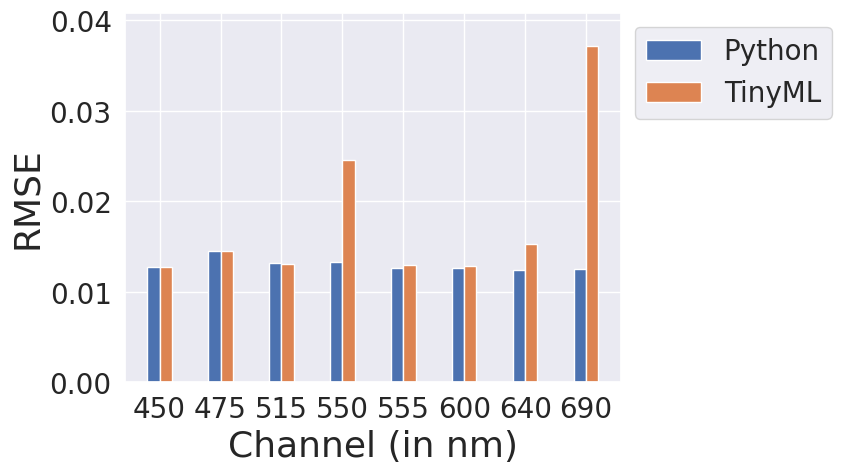

In [ ]:
print(f'Python: {RMSE_calib['Python']}')
print(f'TinyML: {RMSE_calib['TinyML']}')

to_plot = {'Python': RMSE_calib['Python'],
           'TinyML': RMSE_calib['TinyML']}

plotMetric(to_plot, "RMSE", exclude_baseline=False)

## Plot Calibrated Spectrum

       450nm     475nm     515nm     550nm     555nm     600nm     640nm  \
1   0.006648  0.008177  0.007666  0.009755  0.009530  0.008868  0.008532   
8   0.006250  0.007999  0.008204  0.009074  0.009151  0.009118  0.008519   
9   0.006336  0.007896  0.007786  0.009802  0.009169  0.009498  0.008662   
10  0.017196  0.016424  0.015694  0.019543  0.017597  0.017515  0.017071   
16  0.017478  0.016856  0.015768  0.019640  0.017796  0.017523  0.016912   

       690nm  
1   0.011106  
8   0.011067  
9   0.011145  
10  0.023802  
16  0.023762  
chlo1


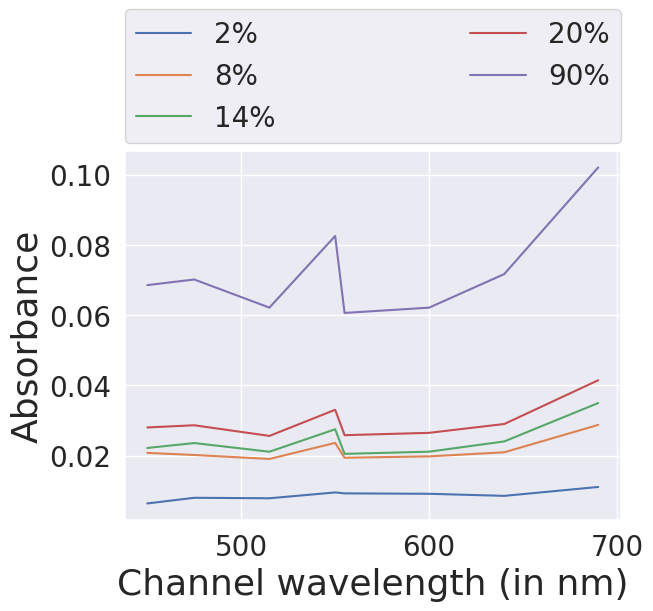

diat1


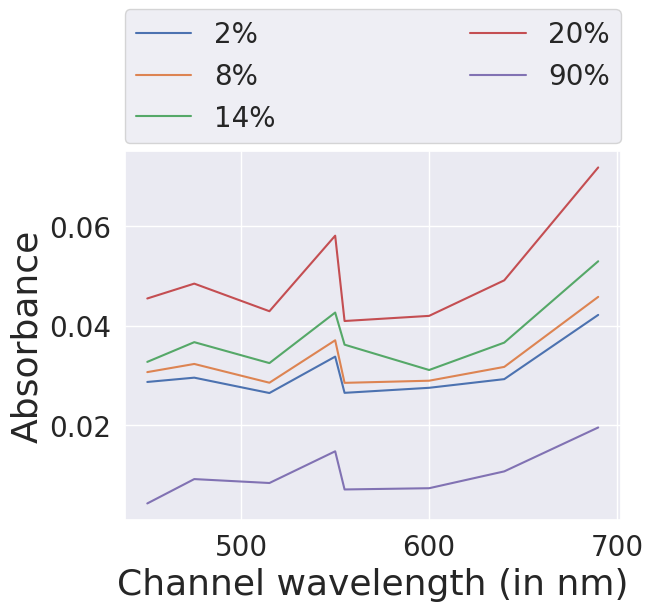

dino1


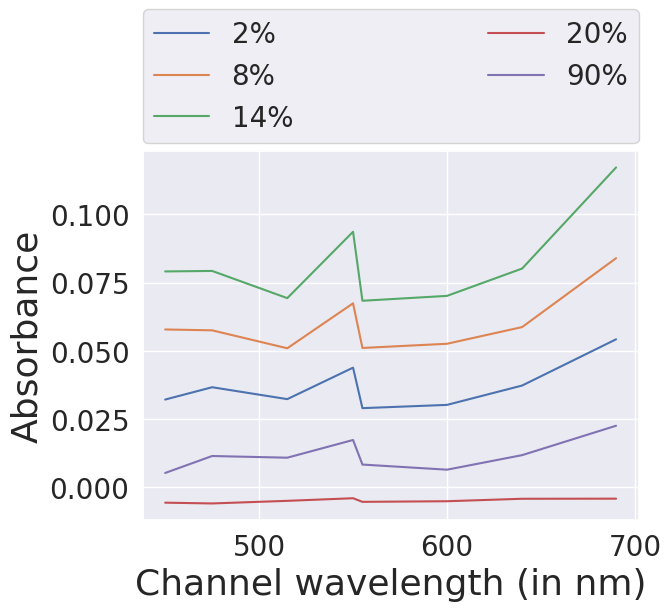

dino2


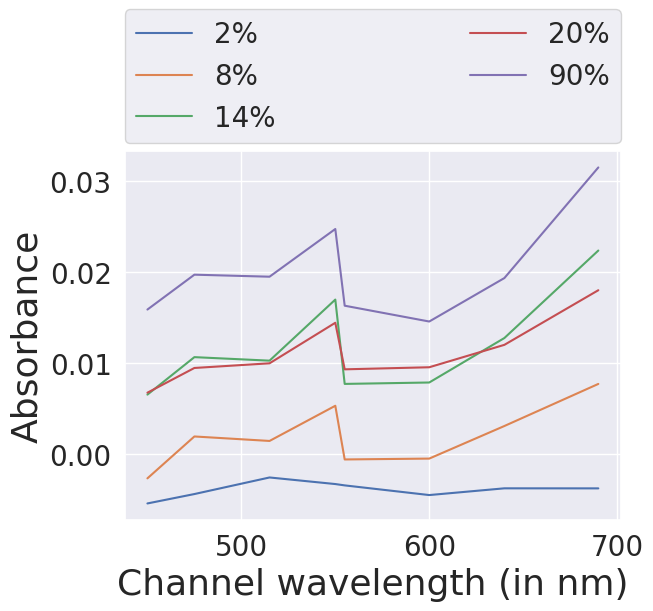

dino3


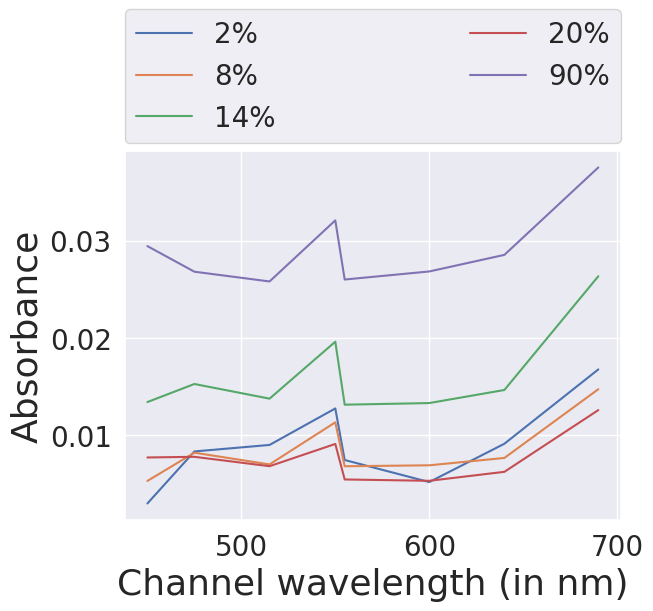

In [ ]:
unsorted_idx = raw_df.index
stm_unsorted = stm_df.set_index(unsorted_idx)
stm_sorted = stm_unsorted.sort_index()
stm_sorted = stm_sorted.drop(stm_sorted.columns[8:], axis=1)
print(stm_sorted.head())

to_plot = {}
percents = [2,4,6,8,10,12,14,16,18,20,25,30,35,40,45,50,60,70,80,90,100]
n_percents = len(percents)
n_reps = 3 # number of rep measurements per percent per species
for n in range(len(species_list)):
  to_plot[species_list[n]] = {}
  for p in [0,3,6,9,19]:
    percent = percents[p]
    start = (n*n_percents)+(p*n_reps)
    end = start + n_reps
    spectrum = [fmean( stm_sorted.iloc[start:end,ch] ) for ch in range(0,8)]
    to_plot[species_list[n]][str(percent)+'%'] = spectrum

for species in to_plot.keys():
  print(species)
  plotSpectrum(to_plot[species], '')

## Classification Comparison

['xgb_d', 'rf', 'svc']

XGBClassifier ------------------------------------------


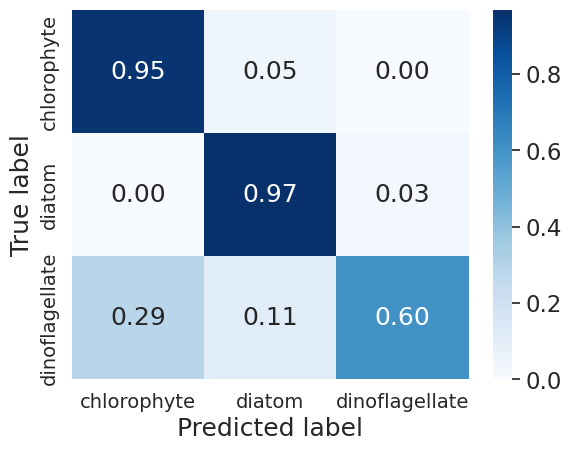

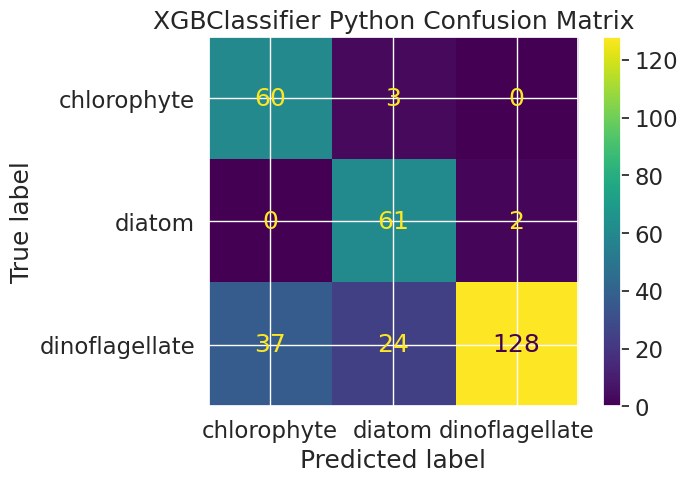


RandomForestClassifier ------------------------------------------


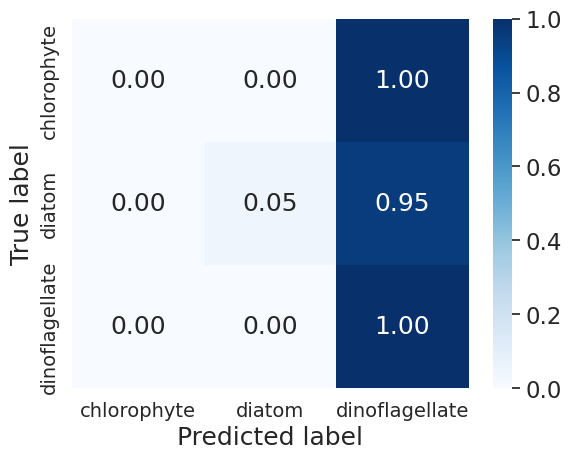

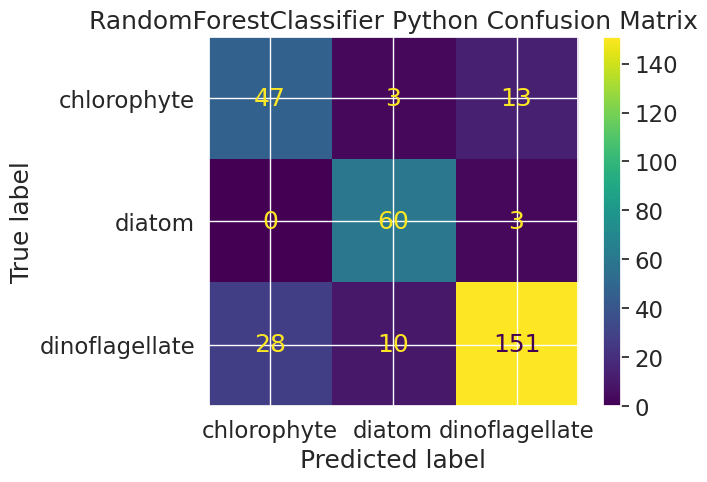


SVC ------------------------------------------


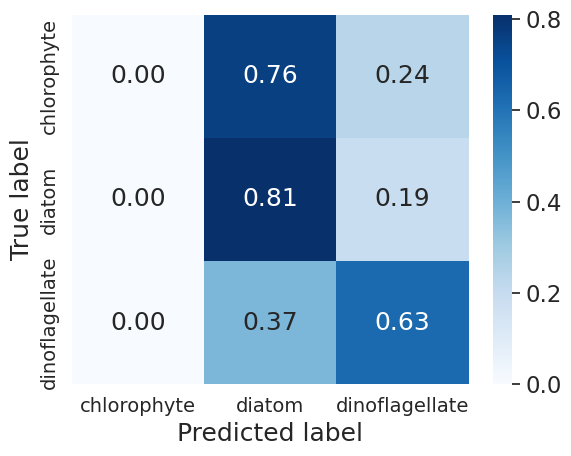

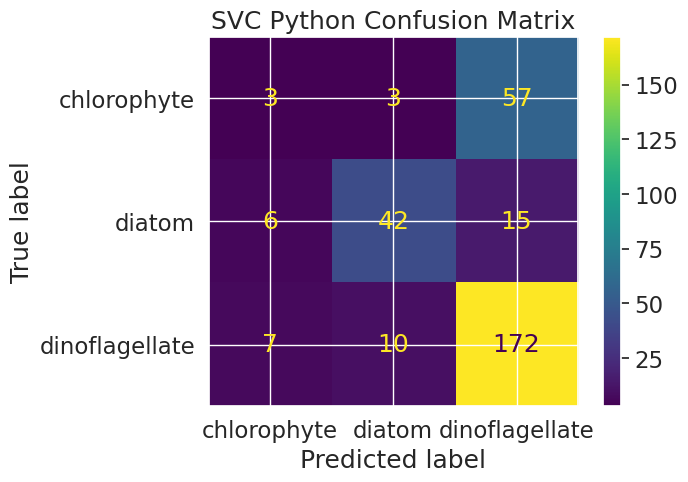


KNeighborsClassifier ------------------------------------------


In [ ]:
cols = ['xgb_d', 'rf', 'svc']
print(cols)
acc_tinyml = {}


# X_input = stm_df.drop(['rf', 'svc', 'xgb_f', 'xgb_d'], axis=1)
X_input = stm_df.iloc[:,0:8]
for name, model in classification_models.items():
  print(f'\n{name} ------------------------------------------')
  idx = list(classification_models.keys()).index(name)
  if (idx >= 3):
    continue

  y_pred = stm_df[cols[idx]]
  y_ref = ref_df['group']
  # print(f'tinyML output:  {list(y_pred)}')
  cm = confusion_matrix(y_ref, y_pred, labels=[model.classes_], normalize='true')

  ax = plt.subplot()
  sns.heatmap(cm, annot=True, ax=ax, cmap="Blues", fmt=".2f");

  # Labels, title and ticks
  label_font = {'size':'18'}  # Adjust to fit
  ax.set_xlabel('Predicted label', fontdict=label_font);
  ax.set_ylabel('True label', fontdict=label_font);

  ax.tick_params(axis='both', which='major', labelsize=14)  # Adjust to fit
  ax.xaxis.set_ticklabels(['chlorophyte', 'diatom', 'dinoflagellate']);
  ax.yaxis.set_ticklabels(['chlorophyte', 'diatom', 'dinoflagellate']);
  plt.show()

  # cm = confusion_matrix(y_ref, y_pred, labels=[model.classes_])
  # disp = ConfusionMatrixDisplay(confusion_matrix=cm,
  #                               display_labels=['chlorophyte', 'diatom', 'dinoflagellate'])
  # disp.plot()
  # plt.title(f'{name} tinyML Confusion Matrix')
  # plt.show()

  y_pred = model.predict(X_input)
  # print(f'Python output:  {[x.item() for x in y_pred]}')
  y_ref = ref_df['group']
  # print(f'Correct output: {list(y_ref)}\n')
  cm = confusion_matrix(y_ref, y_pred, labels=[model.classes_])
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['chlorophyte', 'diatom', 'dinoflagellate'])
  disp.plot()
  plt.title(f'{name} Python Confusion Matrix')
  plt.show()

### Stratified

1       0
8       0
9       0
214     1
213     1
       ..
1045    2
1044    2
209     0
206     0
202     0
Name: group, Length: 225, dtype: int64
1       1
8       1
9       1
214     1
213     1
       ..
1045    2
1044    2
209     0
206     0
202     0
Name: xgb_d, Length: 225, dtype: int64


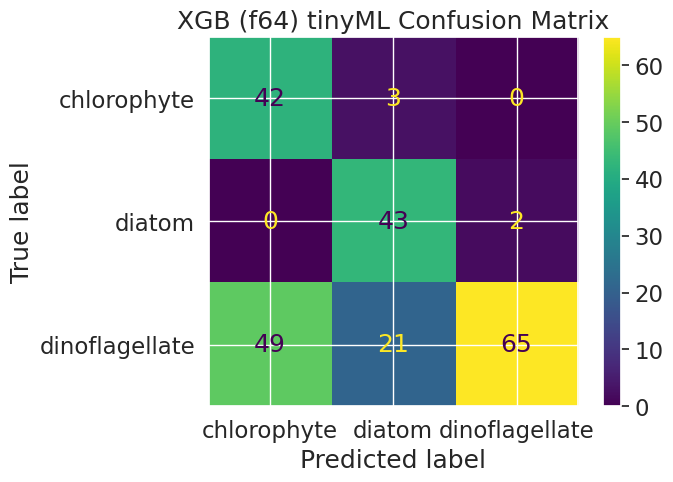

In [ ]:
unsorted_idx = raw_df.index
data_np = stm_df.iloc[1:,:].copy()
stm_unsorted = stm_df.set_index(unsorted_idx)
# print(stm_unsorted.head())

raw_sorted = raw_df.sort_index()
ref_sorted = ref_df.sort_index()
stm_sorted = stm_unsorted.sort_index()
stm_sorted = pd.concat([ref_sorted['percent'], stm_sorted], axis=1)


stm_sorted_percent = stm_sorted.sort_values(by=['percent'])
ref_sorted_percent = ref_sorted.sort_values(by=['percent'])
# print(stm_sorted_percent.head())
# print(ref_sorted_percent.head())
start=0*3*5
end=11*3*5
ref1 = ref_sorted_percent['group'][start:end]
ref2 = ref_sorted_percent['group'][17*3*5:21*3*5]
stm1 = stm_sorted_percent['xgb_d'][start:end]
stm2 = stm_sorted_percent['xgb_d'][17*3*5:21*3*5]

# print(stm_sorted_percent['percent'][start:end])
y_ref = pd.concat([ref1, ref2], axis=0)
y_pred = pd.concat([stm1, stm2], axis=0)
print(y_ref)
print(y_pred)

cm = confusion_matrix(y_ref, y_pred, labels=[model.classes_])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['chlorophyte', 'diatom', 'dinoflagellate'])

disp.plot()
plt.title(f'XGB (f64) tinyML Confusion Matrix')
plt.show()

In [ ]:
code_ls = {'XGBClassifier': 'xgb_d', 'RandomForestClassifier': 'rf', 'SVC': 'svc'}

mdl_name = 'XGBClassifier'
classifier = classification_models[mdl_name]
stm_class = code_ls[mdl_name]

acc_tiny = {}

for i in range(len(species_list)):

  acc_tiny[species_list[i]] = []
  for p in range(n_conc-st_conc):
    start = (i*(n_conc-st_conc)*n_test)+(p*n_test)
    end = start + n_test
    # X = X_test_sorted.iloc[start:end, :8]
    y_ref = ref_sorted['group'][start:end]
    y_pred = stm_sorted[stm_class][start:end]

    # y_pred = classifier.predict(X)

    acc_tiny[species_list[i]].append(accuracy_score(y_ref, y_pred))
  # print(acc[species_list[i]])

acc_tiny['dino'] = [fmean([acc_tiny['dino1'][i], acc_tiny['dino2'][i], acc_tiny['dino3'][i]]) for i in range(n_conc-st_conc)]

print(acc_tiny['chlo1'])
print(acc_tiny['diat1'])
print(acc_tiny['dino'])
# print(acc_tiny['dino2'])
# print(acc_tiny['dino3'])

[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3333333333333333]
[0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.0, 0.5555555555555555, 0.3333333333333333, 0.1111111111111111, 0.3333333333333333, 0.3333333333333333, 0.5555555555555555, 0.6666666666666666, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8888888888888888, 0.7777777777777778, 0.6666666666666666, 0.4444444444444444]


## Concentration Comparison

In [ ]:
X_input = stm_df.iloc[:,0:8]
y_test = clb_df['percent']

# avg_diff = np.float64(0)
# sum_diff = np.float64(0)
# for i in range(X_input.shape[0]): # every row
#   for j in range(X_input.shape[1]): # every column
#     sum_diff += abs(np.float64(X_input.iloc[i,j] - regr_data['X_test'].iloc[i,j]))
# avg_diff = sum_diff/(X_input.shape[0]*X_input.shape[1])
# print('Average difference: ', avg_diff)
# print(X_input)
# print(regr_data['X_test'])

for name, model in regr_models.items():
  y_pred = model.predict(regr_data['X_test'])
  smse = round(np.sqrt(mse(y_test, y_pred)), 10)
  print(f'{name}: {smse}')

model = regr_models['XGBRegressor']


y_pyth = model.predict(X_input)
sr2 = round(r2_score(y_test, y_pyth), 10)
smse = round(np.sqrt(mse(y_test, y_pyth)), 10)
print('XGB Python: ', smse)

y_tiny = stm_df['regr_xgb_f']
sr2 = round(r2_score(y_test, y_tiny), 10)
smse = round(np.sqrt(mse(y_test, y_tiny)), 10)
print('XGB tinyML: ', smse)

NameError: name 'regr_models' is not defined

# Comparison with R-pi

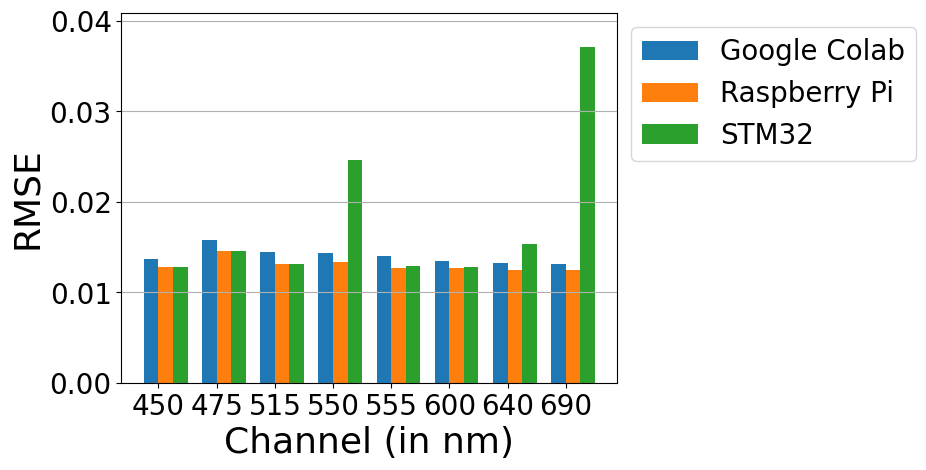

In [ ]:
calib_RMSE_per_platform = {}
calib_RMSE_per_platform['Google Colab'] = RMSE_calib['LinearRegression']
calib_RMSE_per_platform['Raspberry Pi'] = np.array([0.0127444975, 0.0145377262, 0.0131353462, 0.0133215319, 0.0126775548, 0.012622388, 0.0124270614, 0.0124747148], dtype=np.float32())
calib_RMSE_per_platform['STM32'] = RMSE_calib['TinyML']

plotMetric(calib_RMSE_per_platform, 'RMSE', exclude_baseline=False)